In [1]:
import ROOT
import numpy as np
import uproot as ur
import awkward as ak
import os
import matplotlib.pyplot as plt
import mplhep as hep
hep.style.use("CMS")
hep.style.use(hep.style.CMS)
import matplotlib.colors as mcolors
from matplotlib import colormaps
from scipy.optimize import curve_fit
import pandas as pd
from mpl_toolkits.axes_grid1 import make_axes_locatable

from cycler import cycler
plt.rcParams["axes.prop_cycle"] = cycler('color', ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'])

In [2]:
load_trained_omnifold_model = False
num_to_train_with = 100000
num_sectors = 6
use_unfolding = False
E_beam = 10.547
include_data = True

In [3]:
def np_to_TVector(array):
    vector = ROOT.TVector(len(array))
    for i, entry in enumerate(array):
        vector[i] = entry
    return vector
def TVector_to_np(vector):
    out_array = []
    for i in range(vector.GetNoElements()):
        out_array.append(vector[i])
    return np.array(out_array)

In [4]:
MC1_name = "clasdis"
MC2_name = "GiBUU"
plot_title = f"{MC1_name} vs. {MC2_name}: C/LD2"

In [5]:
separated_sim_liquid_and_solid = True
directories = {"MC1_liquid" : "/media/miguel/Elements_2024/CLAS_data/C/electron_candidates/",
               "MC1_solid" : "/media/miguel/Elements_2024/CLAS_data/C/electron_candidates/",
               "MC2_liquid" : "/media/miguel/Elements_2024/CLAS_data/C/electron_candidates/",
               "MC2_solid" : "/media/miguel/Elements_2024/CLAS_data/C/electron_candidates/",
               "data" : "/media/miguel/Elements_2024/CLAS_data/C/electron_candidates/",
              }
file_names = {"MC1_liquid" : "electron_candidates_notargetcuts_withfiducialcuts_W2GeVcut_LD2Cliquid_clasdis_deuteron_zh0_3000files.root",
              "MC1_solid" : "electron_candidates_notargetcuts_withfiducialcuts_W2GeVcut_LD2Csolid_clasdis_deuteron_zh0_3000files.root",
              "MC2_liquid" : "electron_candidates_notargetcuts_withfiducialcuts_W2GeVcut_LD2Cliquid_gibuu_deuteron_3000files.root",
              "MC2_solid" : "electron_candidates_notargetcuts_withfiducialcuts_W2GeVcut_LD2Csolid_gibuu_carbon_3000files.root",
              "data":"electron_candidates_notargetcuts_withfiducialcuts_W2GeVcut_020131-020176_pass08.root",
             }

branches_dict = {}
for name in directories:
    with ur.open(f"{os.path.join(directories[name], file_names[name])}:electrons") as events:
        branches = events.arrays()
        permutation = np.random.permutation(len(branches))
        branches_shuffled = branches[permutation]
        branches_dict[name] = branches_shuffled

In [6]:
if separated_sim_liquid_and_solid:
    branches_dict["MC1_solid"]["weight"] = .75
    branches_dict["MC1_liquid"]["weight"] = 1
    branches_dict["MC1"] = ak.concatenate([branches_dict["MC1_liquid"], branches_dict["MC1_solid"]])
    permutation = np.random.permutation(len(branches_dict["MC1"]))
    branches_shuffled = branches_dict["MC1"][permutation]
    branches_dict["MC1"] = branches_shuffled

    branches_dict["MC2_solid"]["weight"] = .75
    branches_dict["MC2_liquid"]["weight"] = 1
    branches_dict["MC2"] = ak.concatenate([branches_dict["MC2_liquid"], branches_dict["MC2_solid"]])
    permutation = np.random.permutation(len(branches_dict["MC2"]))
    branches_shuffled = branches_dict["MC2"][permutation]
    branches_dict["MC2"] = branches_shuffled
else:
    branches_dict["MC1"]["weight"] = 1
    branches_dict["MC2"]["weight"] = 1

In [7]:
print(len(branches_dict["MC1"]["Q2"]))
print(len(branches_dict["MC2"]["Q2"]))

3667220
4368438


In [8]:
variables_to_unfold = ["v_z", "p", "theta_degrees", "phi_degrees", "x", "Q2"]
if not use_unfolding:
    variables_to_unfold = []

In [9]:
if use_unfolding:
    sim_MCreco_dict, sim_MCgen_dict, data_reco_dict = {}, {}, {}
    for variable in variables_to_unfold:
        sim_MCreco_dict[variable] = np.array(branches_dict["MC2"][variable][:])
        sim_MCgen_dict[variable] = np.array(branches_dict["MC2"][variable][:])
        data_reco_dict[variable] = np.array(branches_dict["MC1"][variable][:])

In [10]:
if use_unfolding:
    unbinned_unfolding = ROOT.RooUnfoldOmnifold()
    unbinned_unfolding.SetSaveDirectory("/home/ryan/clas_analysis/clas12-rge-analysis/analysis/")
    # unbinned_unfolding.SetModelName("RGE_carbon_roottuples_withfiducialcuts_W2GeV_5million")
    unbinned_unfolding.SetModelName("RGE_carbon_roottuples_withfiducialcuts_W2GeV_pass08")
    
    if not load_trained_omnifold_model:
        sim_MCreco_dict, sim_MCgen_dict, data_reco_dict = {}, {}, {}
        for variable in variables_to_unfold:
            sim_MCreco_dict[variable] = np.array(branches_dict["MC2"][variable][:num_to_train_with])
            sim_MCgen_dict[variable] = np.array(branches_dict["MC2"][variable][:num_to_train_with])
            data_reco_dict[variable] = np.array(branches_dict["MC1"][variable][:num_to_train_with])
        df_MCgen = ROOT.RDF.FromNumpy(sim_MCreco_dict)
        df_MCreco = ROOT.RDF.FromNumpy(sim_MCgen_dict)
        df_measured = ROOT.RDF.FromNumpy(data_reco_dict)
        unbinned_unfolding.SetMCgenDataFrame(df_MCgen)
        unbinned_unfolding.SetMCrecoDataFrame(df_MCreco)
        unbinned_unfolding.SetMeasuredDataFrame(df_measured)
        unbinned_unfolding.SetNumIterations(1)
        unbinned_results = unbinned_unfolding.UnbinnedOmnifold()

In [11]:
if use_unfolding:
    sim_MCreco_dict, sim_MCgen_dict, data_reco_dict = {}, {}, {}
    for variable in variables_to_unfold:
        sim_MCreco_dict[variable] = np.array(branches_dict["MC2"][variable][:])
        sim_MCgen_dict[variable] = np.array(branches_dict["MC2"][variable][:])
    df_MCgen = ROOT.RDF.FromNumpy(sim_MCreco_dict)
    df_MCreco = ROOT.RDF.FromNumpy(sim_MCgen_dict)
    unbinned_unfolding.SetTestMCgenDataFrame(df_MCgen)
    unbinned_unfolding.SetTestMCrecoDataFrame(df_MCreco)
    test_unbinned_results = unbinned_unfolding.TestUnbinnedOmnifold()
    step1_test_weights_TVector = ROOT.std.get[0](test_unbinned_results)
    step2_test_weights_TVector = ROOT.std.get[1](test_unbinned_results)
    step1_weights = TVector_to_np(step1_test_weights_TVector)

Text(0.5, 1.0, 'clasdis vs. GiBUU: C/LD2')

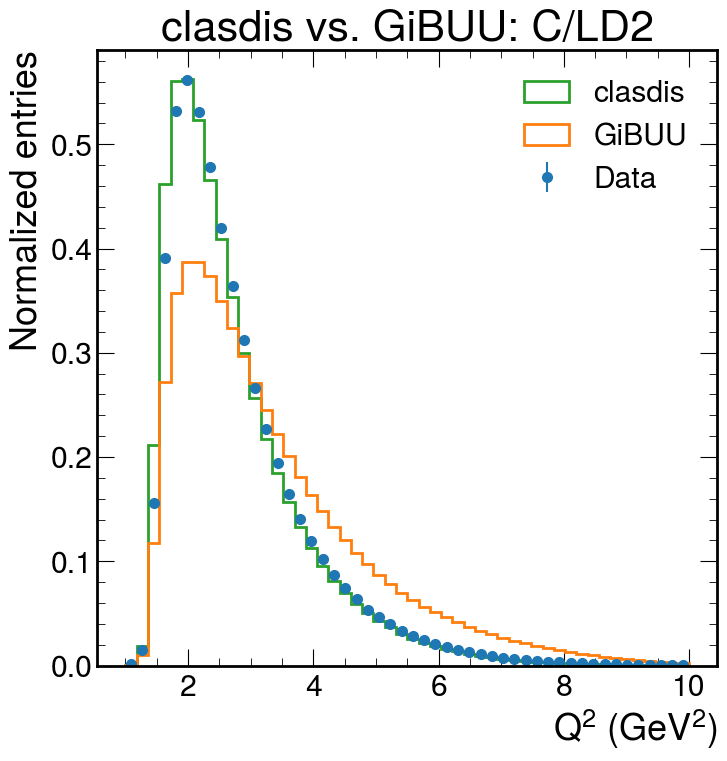

In [12]:
low_bin, high_bin, num_bins = 1, 10, 50

fig =  plt.figure(figsize=(8,8))

data_counts, data_bin_edges = np.histogram(
    branches_dict["data"]["Q2"],
    bins = num_bins,
    range = (low_bin, high_bin),
)
data_errors = np.sqrt(data_counts)

total_data_entries = np.sum(data_counts)
data_bin_widths = np.diff(data_bin_edges)
normalized_data_counts = data_counts / (total_data_entries * data_bin_widths)
normalized_data_errors = data_errors / (total_data_entries * data_bin_widths)
data_bin_centers = (data_bin_edges[:-1] + data_bin_edges[1:])/2

if include_data:
    plt.errorbar(
        data_bin_centers,
        normalized_data_counts,
        yerr = normalized_data_errors,
        fmt = 'o',
        color= '#1f77b4',
        label = "Data",
        markersize = 7,
    )
plt.hist(
    branches_dict["MC1"]["Q2"],
    weights = branches_dict["MC1"]["weight"],
    bins = num_bins,
    range=(low_bin, high_bin),
    density=True,
    label = MC1_name,
    histtype='step',
    color='#2ca02c',
    linewidth=2
)

plt.hist(
    branches_dict["MC2"]["Q2"],
    weights = branches_dict["MC2"]["weight"],
    bins = num_bins,
    range=(low_bin, high_bin),
    density=True,
    label = MC2_name,
    histtype='step',
    color='#ff7f0e',
    linewidth=2
)
if "Q2" in variables_to_unfold:
    plt.hist(
        branches_dict["MC2"]["Q2"],
        weights = step1_weights,
        bins = num_bins,
        range=(low_bin, high_bin),
        density=True,
        label="Reweighted Simulation",
        color='#2ca02c',
        alpha=.5,
    )
plt.xlabel("$Q^2 ~(GeV^2)$")
plt.ylabel("Normalized entries")
plt.legend(loc='upper right')
plt.title(plot_title)

Text(0.5, 1.0, 'clasdis vs. GiBUU: C/LD2')

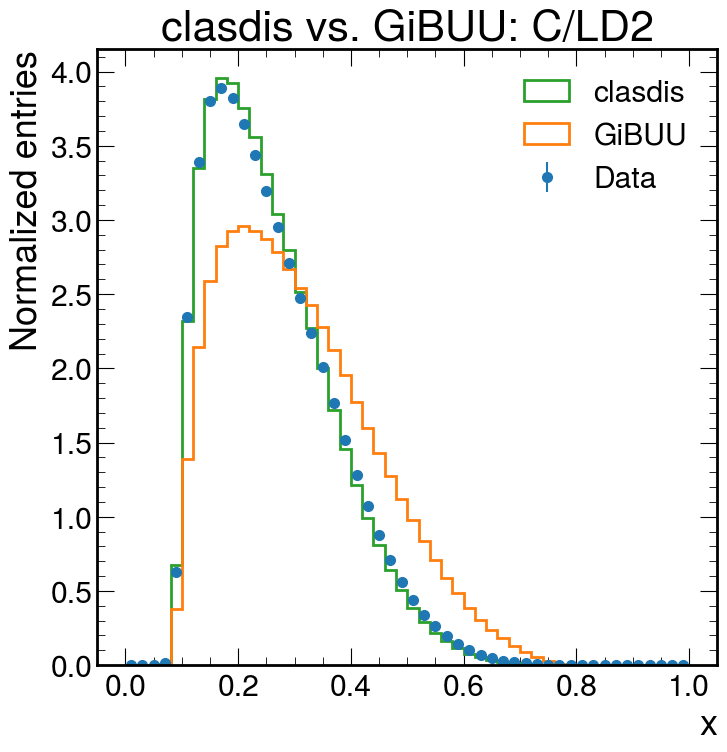

In [13]:
low_bin, high_bin, num_bins = 0, 1, 50

fig =  plt.figure(figsize=(8,8))

data_counts, data_bin_edges = np.histogram(
    branches_dict["data"]["x"],
    bins = num_bins,
    range = (low_bin, high_bin),
)
data_errors = np.sqrt(data_counts)

total_data_entries = np.sum(data_counts)
data_bin_widths = np.diff(data_bin_edges)
normalized_data_counts = data_counts / (total_data_entries * data_bin_widths)
normalized_data_errors = data_errors / (total_data_entries * data_bin_widths)
data_bin_centers = (data_bin_edges[:-1] + data_bin_edges[1:])/2

if include_data:
    plt.errorbar(
        data_bin_centers,
        normalized_data_counts,
        yerr = normalized_data_errors,
        fmt = 'o',
        color= '#1f77b4',
        label = "Data",
        markersize = 7,
    )
plt.hist(
    branches_dict["MC1"]["x"],
    weights = branches_dict["MC1"]["weight"],
    bins = num_bins,
    range=(low_bin, high_bin),
    density=True,
    label = MC1_name,
    histtype='step',
    color='#2ca02c',
    linewidth=2
)
plt.hist(
    branches_dict["MC2"]["x"],
    weights = branches_dict["MC2"]["weight"],
    bins = num_bins,
    range=(low_bin, high_bin),
    density=True,
    label = MC2_name,
    histtype='step',
    color='#ff7f0e',
    linewidth=2
)
if "x" in variables_to_unfold:
    plt.hist(
        branches_dict["MC2"]["x"],
        weights = step1_weights,
        bins = num_bins,
        range=(low_bin, high_bin),
        density=True,
        label="Reweighted Simulation",
        color='#2ca02c',
        alpha=.5,
    )
plt.xlabel("x")
plt.ylabel("Normalized entries")
plt.legend(loc='upper right')
plt.title(plot_title)

Text(0.5, 1.0, 'clasdis vs. GiBUU: C/LD2')

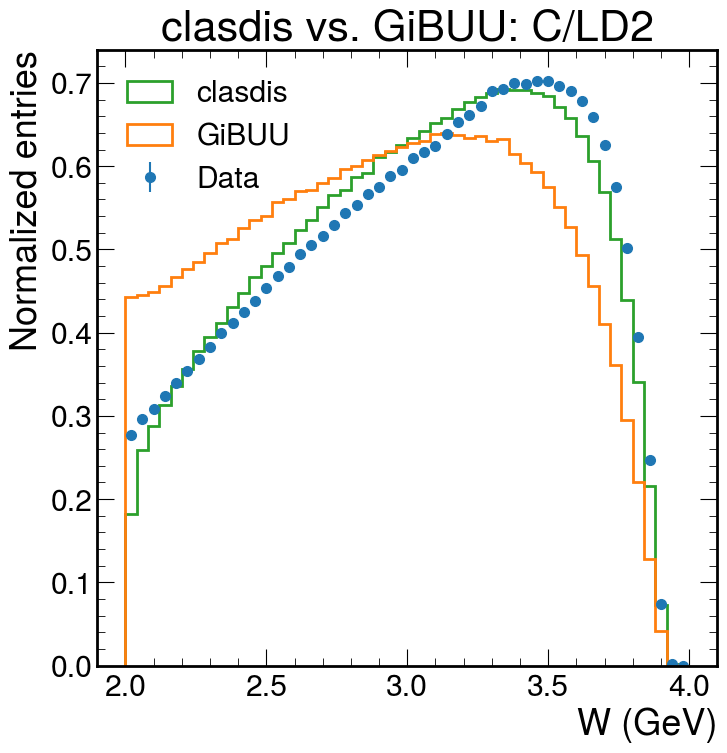

In [14]:
low_bin, high_bin, num_bins = 2, 4, 50

fig =  plt.figure(figsize=(8,8))

data_counts, data_bin_edges = np.histogram(
    branches_dict["data"]["W"],
    bins = num_bins,
    range = (low_bin, high_bin),
)
data_errors = np.sqrt(data_counts)

total_data_entries = np.sum(data_counts)
data_bin_widths = np.diff(data_bin_edges)
normalized_data_counts = data_counts / (total_data_entries * data_bin_widths)
normalized_data_errors = data_errors / (total_data_entries * data_bin_widths)
data_bin_centers = (data_bin_edges[:-1] + data_bin_edges[1:])/2

if include_data:
    plt.errorbar(
        data_bin_centers,
        normalized_data_counts,
        yerr = normalized_data_errors,
        fmt = 'o',
        color= '#1f77b4',
        label = "Data",
        markersize = 7,
    )
plt.hist(
    branches_dict["MC1"]["W"],
    weights = branches_dict["MC1"]["weight"],
    bins = num_bins,
    range=(low_bin, high_bin),
    density=True,
    label = MC1_name,
    histtype='step',
    color='#2ca02c',
    linewidth=2
)
plt.hist(
    branches_dict["MC2"]["W"],
    weights = branches_dict["MC2"]["weight"],
    bins = num_bins,
    range=(low_bin, high_bin),
    density=True,
    label = MC2_name,
    histtype='step',
    color='#ff7f0e',
    linewidth=2
)
if "W" in variables_to_unfold:
    plt.hist(
        branches_dict["MC2"]["W"],
        weights = step1_weights,
        bins = num_bins,
        range=(low_bin, high_bin),
        density=True,
        label="Reweighted Simulation",
        color='#2ca02c',
        alpha=.5,
    )
plt.xlabel("W (GeV)")
plt.ylabel("Normalized entries")
plt.legend(loc='upper left')
plt.title(plot_title)

Text(0.5, 1.0, 'clasdis vs. GiBUU: C/LD2')

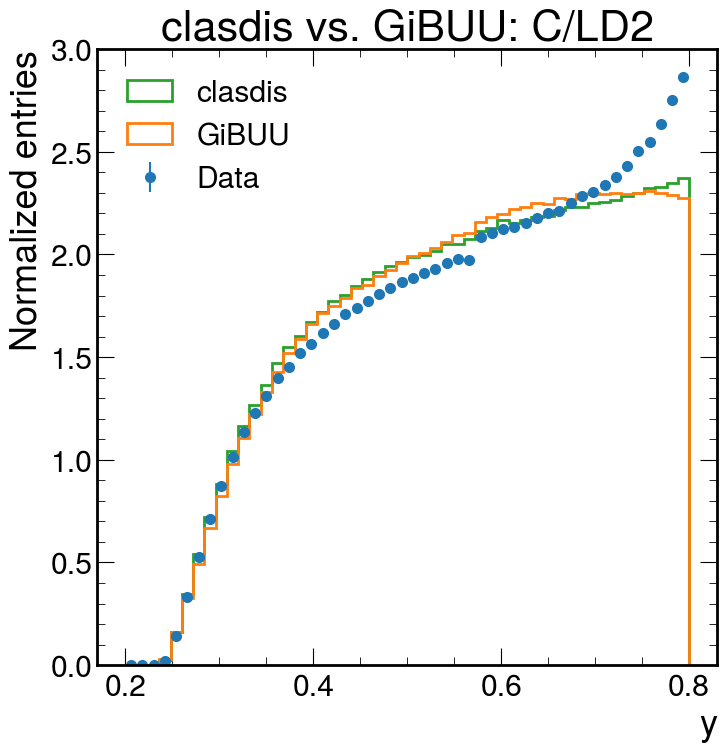

In [15]:
low_bin, high_bin, num_bins = .2, .8, 50

fig =  plt.figure(figsize=(8,8))

data_counts, data_bin_edges = np.histogram(
    branches_dict["data"]["y"],
    bins = num_bins,
    range = (low_bin, high_bin),
)
data_errors = np.sqrt(data_counts)

total_data_entries = np.sum(data_counts)
data_bin_widths = np.diff(data_bin_edges)
normalized_data_counts = data_counts / (total_data_entries * data_bin_widths)
normalized_data_errors = data_errors / (total_data_entries * data_bin_widths)
data_bin_centers = (data_bin_edges[:-1] + data_bin_edges[1:])/2

if include_data:
    plt.errorbar(
        data_bin_centers,
        normalized_data_counts,
        yerr = normalized_data_errors,
        fmt = 'o',
        color= '#1f77b4',
        label = "Data",
        markersize = 7,
    )
plt.hist(
    branches_dict["MC1"]["y"],
    weights = branches_dict["MC1"]["weight"],
    bins = num_bins,
    range=(low_bin, high_bin),
    density=True,
    label = MC1_name,
    histtype='step',
    color='#2ca02c',
    linewidth=2
)
plt.hist(
    branches_dict["MC2"]["y"],
    weights = branches_dict["MC2"]["weight"],
    bins = num_bins,
    range=(low_bin, high_bin),
    density=True,
    label = MC2_name,
    histtype='step',
    color='#ff7f0e',
    linewidth=2
)
if "y" in variables_to_unfold:
    plt.hist(
        branches_dict["MC2"]["y"],
        weights = step1_weights,
        bins = num_bins,
        range=(low_bin, high_bin),
        density=True,
        label="Reweighted Simulation",
        color='#2ca02c',
        alpha=.5,
    )
plt.xlabel("y")
plt.ylabel("Normalized entries")
plt.legend(loc='upper left')
plt.ylim(0,3)
plt.title(plot_title)

Text(0.5, 1.0, 'clasdis vs. GiBUU: C/LD2')

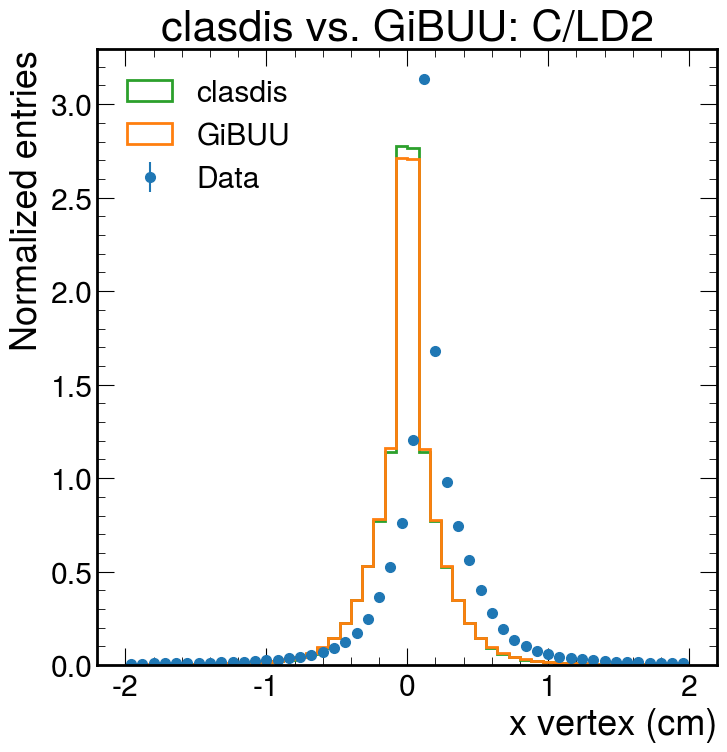

In [16]:
low_bin, high_bin, num_bins = -2, 2, 50

fig =  plt.figure(figsize=(8,8))

data_counts, data_bin_edges = np.histogram(
    branches_dict["data"]["v_x"],
    bins = num_bins,
    range = (low_bin, high_bin),
)
data_errors = np.sqrt(data_counts)

total_data_entries = np.sum(data_counts)
data_bin_widths = np.diff(data_bin_edges)
normalized_data_counts = data_counts / (total_data_entries * data_bin_widths)
normalized_data_errors = data_errors / (total_data_entries * data_bin_widths)
data_bin_centers = (data_bin_edges[:-1] + data_bin_edges[1:])/2

if include_data:
    plt.errorbar(
        data_bin_centers,
        normalized_data_counts,
        yerr = normalized_data_errors,
        fmt = 'o',
        color= '#1f77b4',
        label = "Data",
        markersize = 7,
    )
plt.hist(
    branches_dict["MC1"]["v_x"],
    weights = branches_dict["MC1"]["weight"],
    bins = num_bins,
    range=(low_bin, high_bin),
    density=True,
    label = MC1_name,
    histtype='step',
    color='#2ca02c',
    linewidth=2
)

plt.hist(
    branches_dict["MC2"]["v_x"],
    weights = branches_dict["MC2"]["weight"],
    bins = num_bins,
    range=(low_bin, high_bin),
    density=True,
    label = MC2_name,
    histtype='step',
    color='#ff7f0e',
    linewidth=2
)
if "v_x" in variables_to_unfold:
    plt.hist(
        branches_dict["MC2"]["v_x"],
        weights = step1_weights,
        bins = num_bins,
        range=(low_bin, high_bin),
        density=True,
        label="Reweighted Simulation",
        color='#2ca02c',
        alpha=.5,
        linewidth=2
    )
plt.xlabel("x vertex (cm)")
plt.ylabel("Normalized entries")
plt.legend(loc='upper left')
plt.title(plot_title)

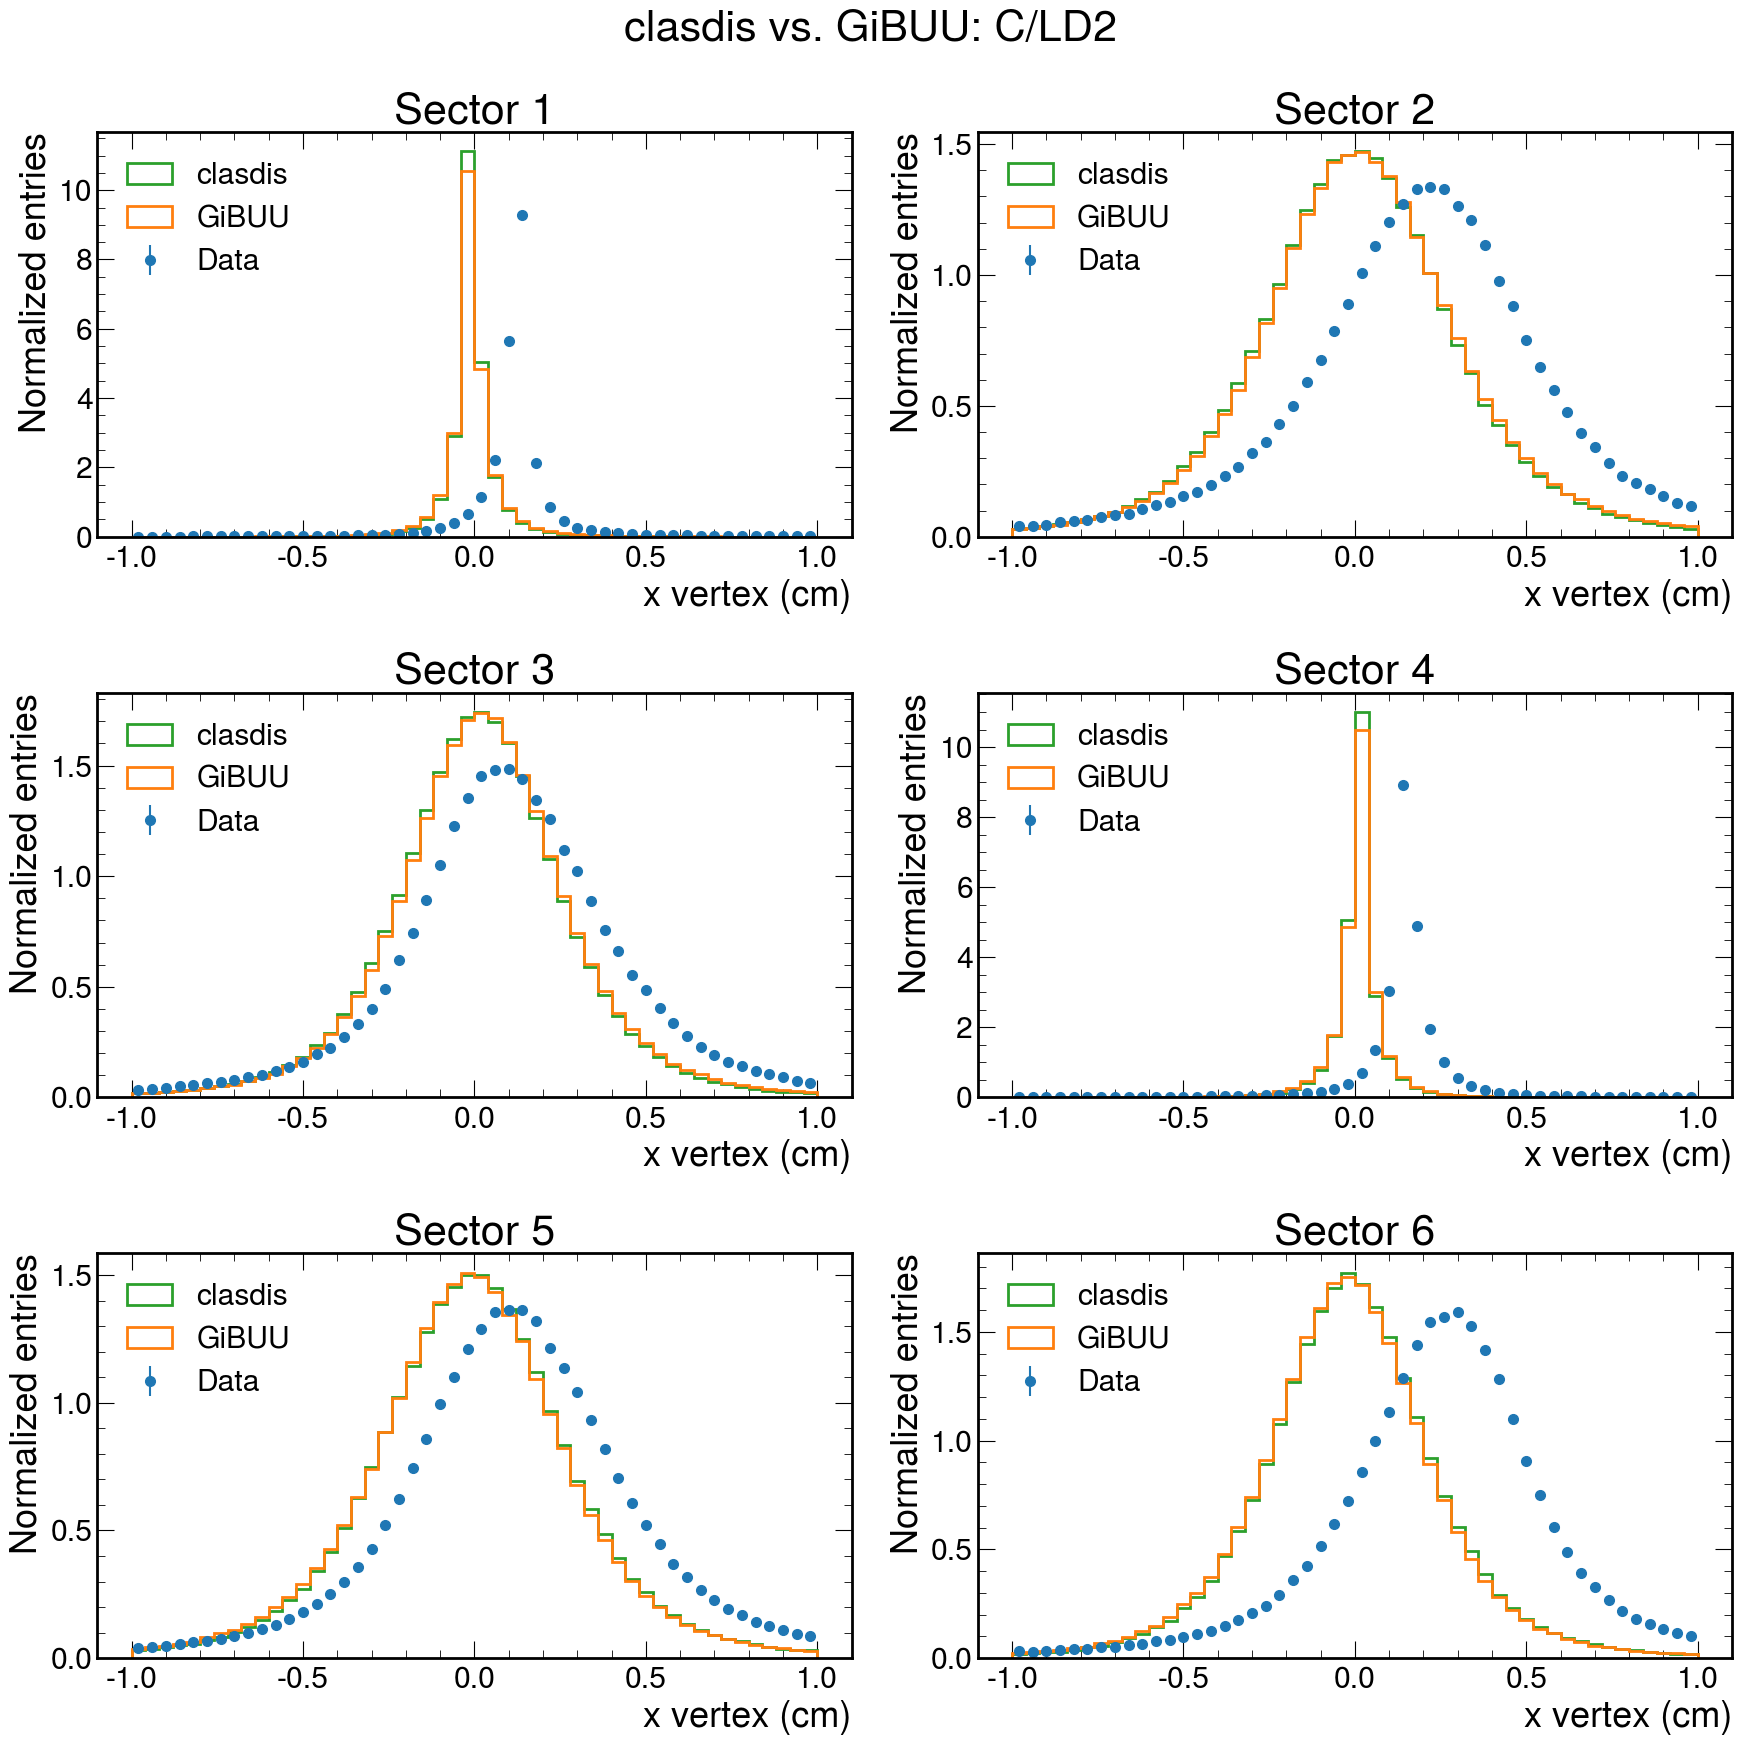

In [17]:
low_bin, high_bin, num_bins = -1, 1, 50

fig, axs = plt.subplots(3, 2, figsize=(18, 18))
axs = axs.flatten()
for sector in range(num_sectors):
    MC1_sector_cut = branches_dict["MC1"]["sector"]==(sector+1)
    MC2_sector_cut = branches_dict["MC2"]["sector"]==(sector+1)

    data_sector_cut = branches_dict["data"]["sector"]==(sector+1)
    data_counts, data_bin_edges = np.histogram(
        branches_dict["data"]["v_x"][data_sector_cut],
        bins = num_bins,
        range = (low_bin, high_bin),
    )
    data_errors = np.sqrt(data_counts)
    
    total_data_entries = np.sum(data_counts)
    data_bin_widths = np.diff(data_bin_edges)
    normalized_data_counts = data_counts / (total_data_entries * data_bin_widths)
    normalized_data_errors = data_errors / (total_data_entries * data_bin_widths)
    data_bin_centers = (data_bin_edges[:-1] + data_bin_edges[1:])/2

    if include_data:
        axs[sector].errorbar(
            data_bin_centers,
            normalized_data_counts,
            yerr = normalized_data_errors,
            fmt = 'o',
            color= '#1f77b4',
            label = "Data",
            markersize = 7,
    )
    axs[sector].hist(
        branches_dict["MC1"]["v_x"][MC1_sector_cut],
        weights = branches_dict["MC1"]["weight"][MC1_sector_cut],
        bins = num_bins,
        range=(low_bin, high_bin),
        density=True,
        label = MC1_name,
        histtype='step',
        color='#2ca02c',
        linewidth=2
    )
    
    axs[sector].hist(
        branches_dict["MC2"]["v_x"][MC2_sector_cut],
        weights = branches_dict["MC2"]["weight"][MC2_sector_cut],
        bins = num_bins,
        range=(low_bin, high_bin),
        density=True,
        label = MC2_name,
        histtype='step',
        color='#ff7f0e',
        linewidth=2
    )
    if "v_x" in variables_to_unfold:
        axs[sector].hist(
            branches_dict["MC2"]["v_x"][MC2_sector_cut],
            weights = step1_weights[MC2_sector_cut],
            bins = num_bins,
            range=(low_bin, high_bin),
            density=True,
            label="Reweighted Simulation",
            color='#2ca02c',
            alpha=.5,
            linewidth=2
        )
    axs[sector].set_xlabel("x vertex (cm)")
    axs[sector].set_ylabel("Normalized entries")
    axs[sector].legend(loc='upper left')
    axs[sector].set_title(f"Sector {sector+1}")
plt.suptitle(plot_title)
plt.tight_layout()


Text(0.5, 1.0, 'clasdis vs. GiBUU: C/LD2')

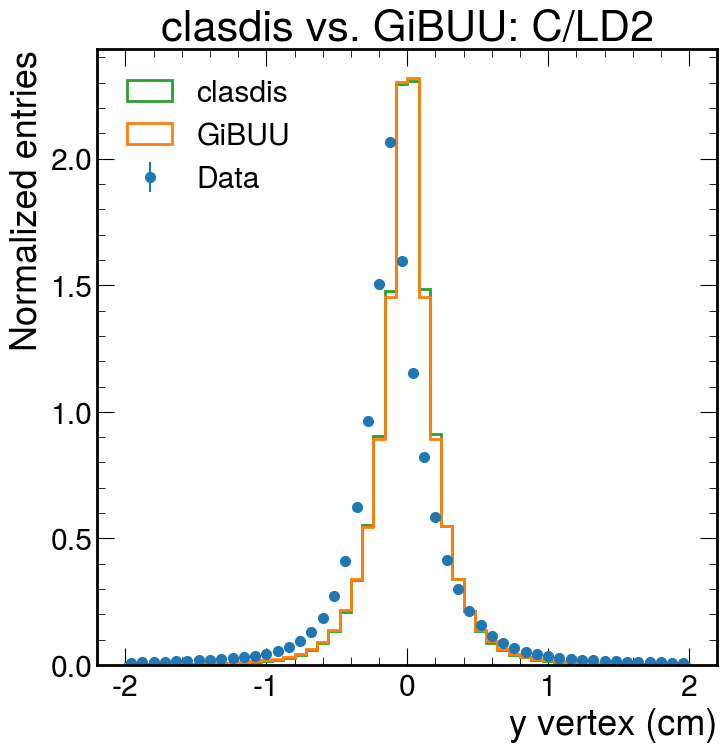

In [18]:
low_bin, high_bin, num_bins = -2, 2, 50

fig =  plt.figure(figsize=(8,8))

data_counts, data_bin_edges = np.histogram(
    branches_dict["data"]["v_y"],
    bins = num_bins,
    range = (low_bin, high_bin),
)
data_errors = np.sqrt(data_counts)

total_data_entries = np.sum(data_counts)
data_bin_widths = np.diff(data_bin_edges)
normalized_data_counts = data_counts / (total_data_entries * data_bin_widths)
normalized_data_errors = data_errors / (total_data_entries * data_bin_widths)
data_bin_centers = (data_bin_edges[:-1] + data_bin_edges[1:])/2

if include_data:
    plt.errorbar(
        data_bin_centers,
        normalized_data_counts,
        yerr = normalized_data_errors,
        fmt = 'o',
        color= '#1f77b4',
        label = "Data",
        markersize = 7,
    )
    
plt.hist(
    branches_dict["MC1"]["v_y"],
    weights = branches_dict["MC1"]["weight"],
    bins = num_bins,
    range=(low_bin, high_bin),
    density=True,
    label = MC1_name,
    histtype='step',
    color='#2ca02c',
    linewidth=2
)

plt.hist(
    branches_dict["MC2"]["v_y"],
    weights = branches_dict["MC2"]["weight"],
    bins = num_bins,
    range=(low_bin, high_bin),
    density=True,
    label = MC2_name,
    histtype='step',
    color='#ff7f0e',
    linewidth=2
)
if "v_y" in variables_to_unfold:
    plt.hist(
        branches_dict["MC2"]["v_y"],
        weights = step1_weights,
        bins = num_bins,
        range=(low_bin, high_bin),
        density=True,
        label="Reweighted Simulation",
        color='#2ca02c',
        alpha=.5,
        linewidth=2
    )
    
plt.xlabel("y vertex (cm)")
plt.ylabel("Normalized entries")
plt.legend(loc='upper left')
plt.title(plot_title)

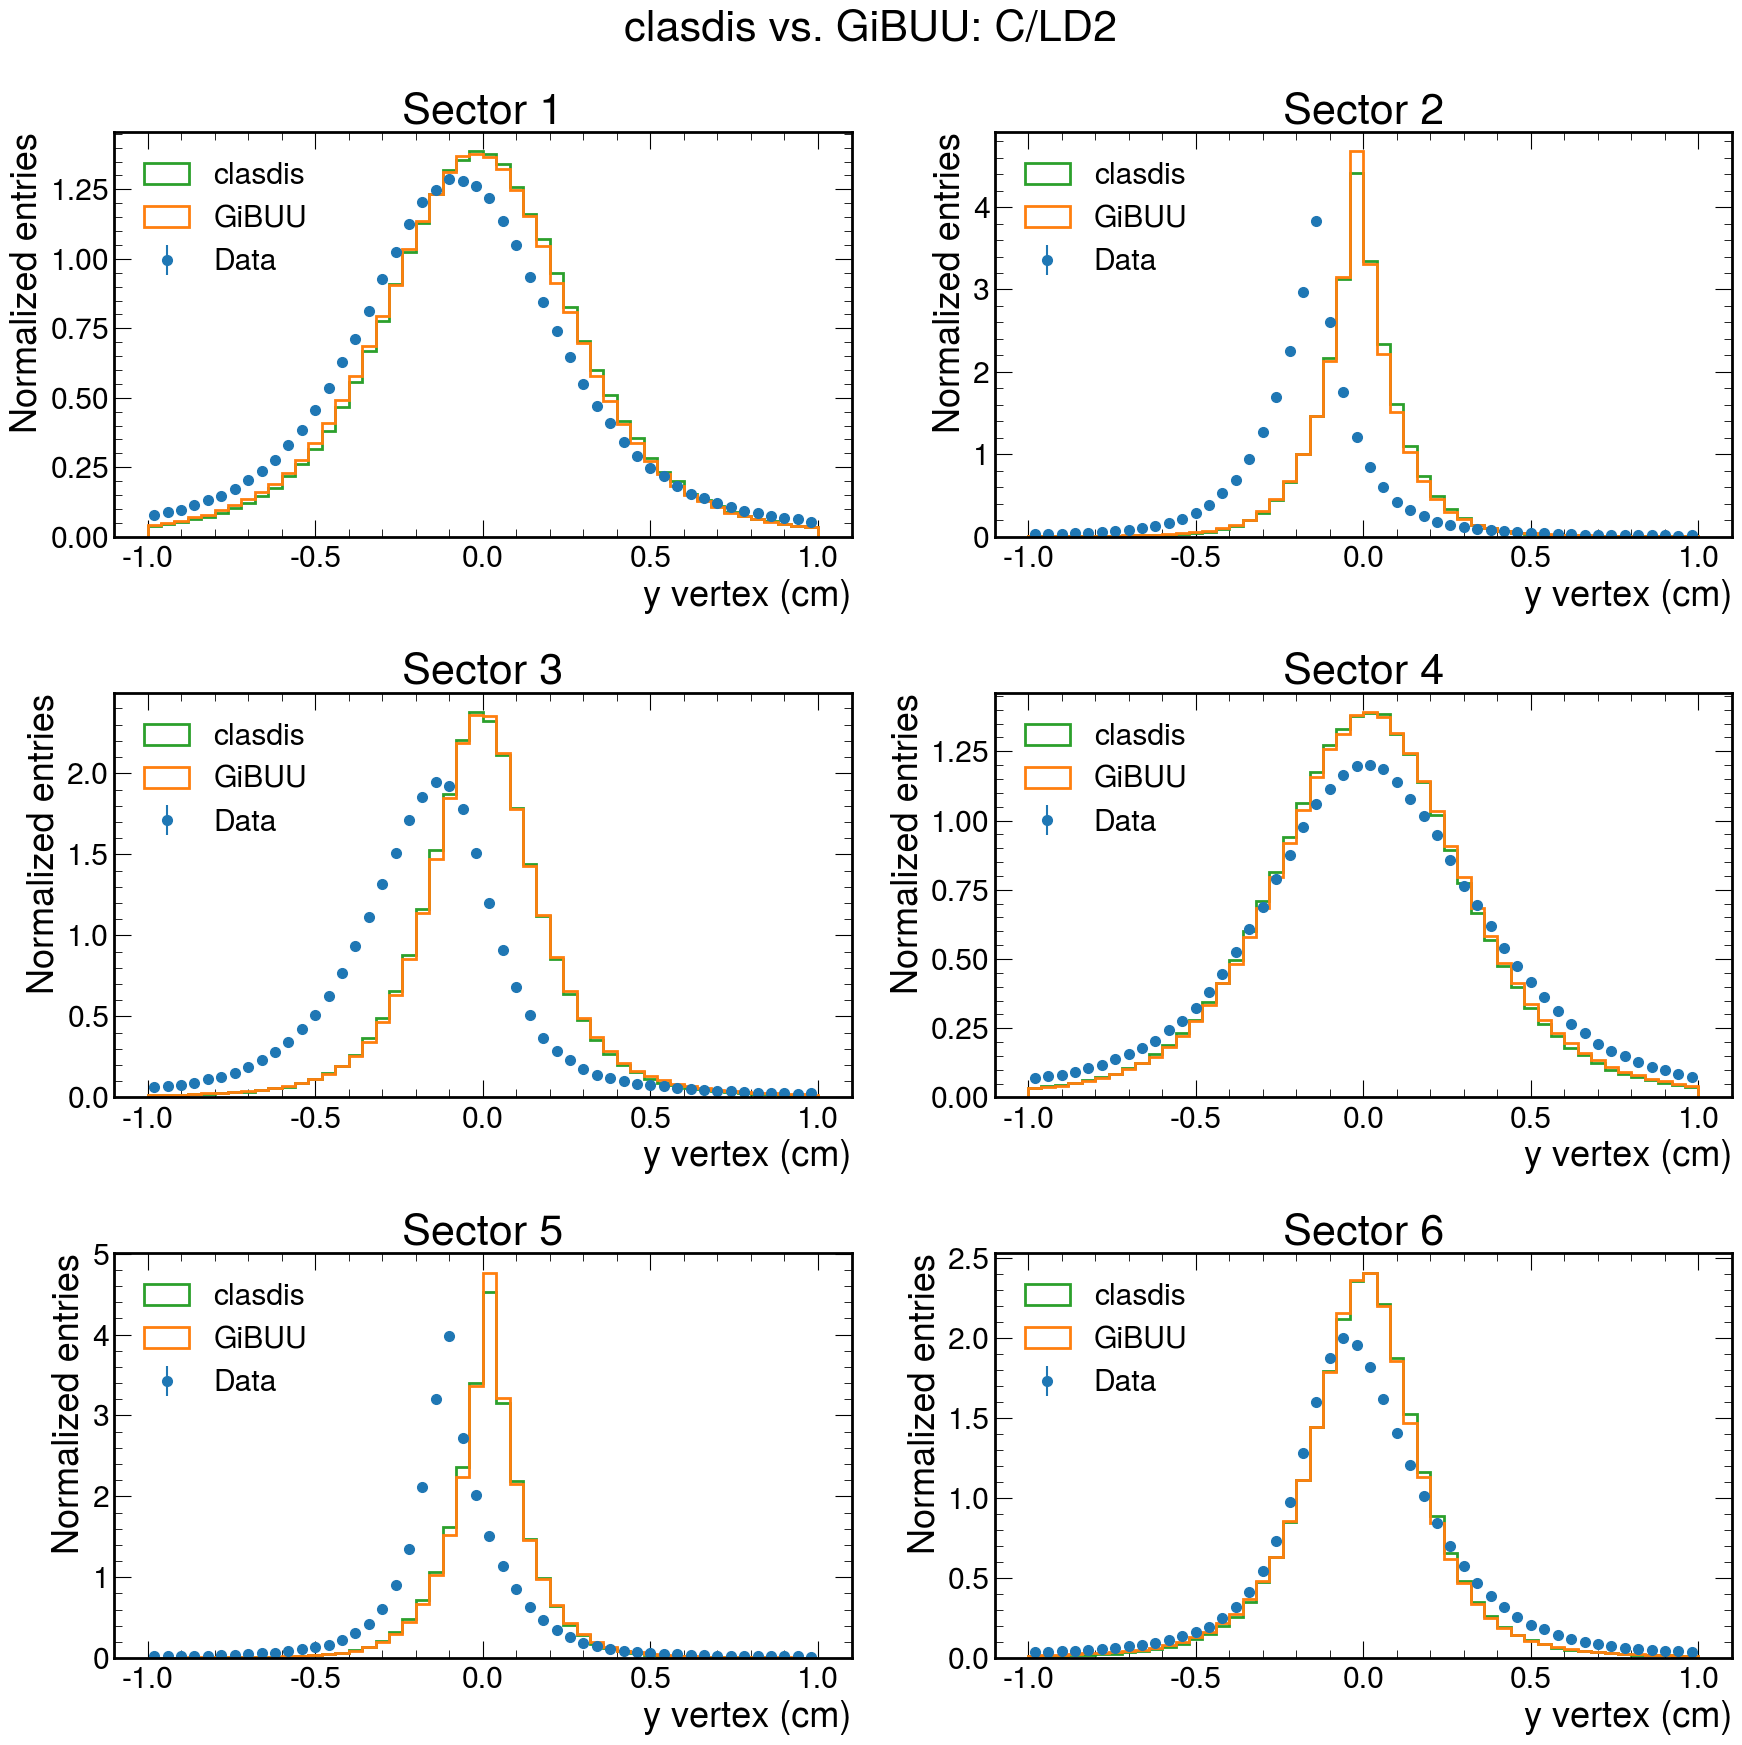

In [20]:
low_bin, high_bin, num_bins = -1, 1, 50

fig, axs = plt.subplots(3, 2, figsize=(18, 18))
axs = axs.flatten()
for sector in range(num_sectors):
    MC1_sector_cut = branches_dict["MC1"]["sector"]==(sector+1)
    MC2_sector_cut = branches_dict["MC2"]["sector"]==(sector+1)

    data_sector_cut = branches_dict["data"]["sector"]==(sector+1)
    data_counts, data_bin_edges = np.histogram(
        branches_dict["data"]["v_y"][data_sector_cut],
        bins = num_bins,
        range = (low_bin, high_bin),
    )
    
    data_errors = np.sqrt(data_counts)
    
    total_data_entries = np.sum(data_counts)
    data_bin_widths = np.diff(data_bin_edges)
    normalized_data_counts = data_counts / (total_data_entries * data_bin_widths)
    normalized_data_errors = data_errors / (total_data_entries * data_bin_widths)
    data_bin_centers = (data_bin_edges[:-1] + data_bin_edges[1:])/2
    if include_data:
        axs[sector].errorbar(
            data_bin_centers,
            normalized_data_counts,
            yerr = normalized_data_errors,
            fmt = 'o',
            color= '#1f77b4',
            label = "Data",
            markersize = 7,
    )
    axs[sector].hist(
        branches_dict["MC1"]["v_y"][MC1_sector_cut],
        weights = branches_dict["MC1"]["weight"][MC1_sector_cut],
        bins = num_bins,
        range=(low_bin, high_bin),
        density=True,
        label = MC1_name,
        histtype='step',
        color='#2ca02c',
        linewidth=2
    )
    
    axs[sector].hist(
        branches_dict["MC2"]["v_y"][MC2_sector_cut],
        weights = branches_dict["MC2"]["weight"][MC2_sector_cut],
        bins = num_bins,
        range=(low_bin, high_bin),
        density=True,
        label = MC2_name,
        histtype='step',
        color='#ff7f0e',
        linewidth=2
    )
    if "v_x" in variables_to_unfold:
        axs[sector].hist(
            branches_dict["MC2"]["v_y"][MC2_sector_cut],
            weights = step1_weights[MC2_sector_cut],
            bins = num_bins,
            range=(low_bin, high_bin),
            density=True,
            label="Reweighted Simulation",
            color='#2ca02c',
            alpha=.5,
            linewidth=2
        )
    axs[sector].set_xlabel("y vertex (cm)")
    axs[sector].set_ylabel("Normalized entries")
    axs[sector].legend(loc='upper left')
    axs[sector].set_title(f"Sector {sector+1}")
plt.suptitle(plot_title)

plt.tight_layout()

Text(0.5, 1.0, 'clasdis vs. GiBUU: C/LD2')

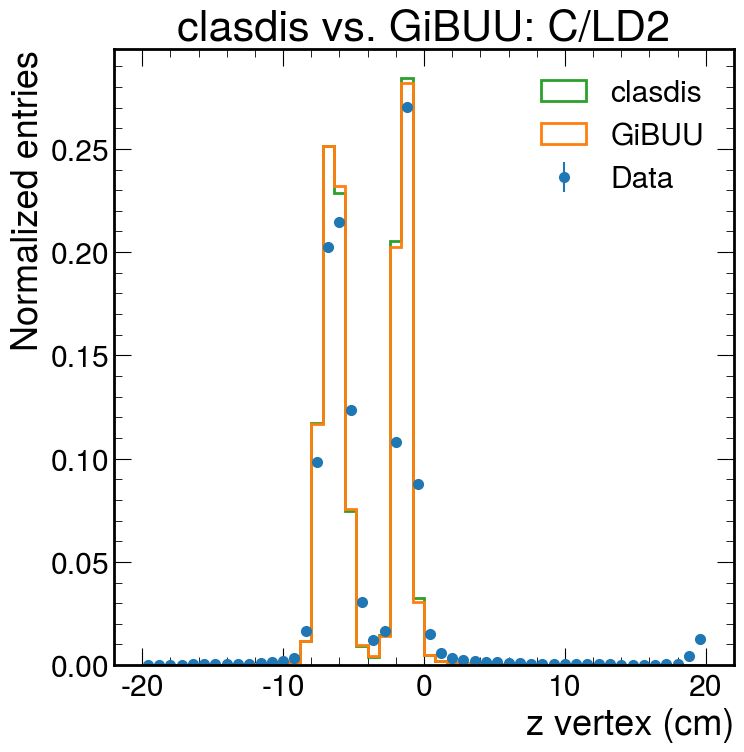

In [21]:
low_bin, high_bin, num_bins = -20, 20, 50

fig =  plt.figure(figsize=(8,8))

data_counts, data_bin_edges = np.histogram(
    branches_dict["data"]["v_z"],
    bins = num_bins,
    range = (low_bin, high_bin),
)
data_errors = np.sqrt(data_counts)

total_data_entries = np.sum(data_counts)
data_bin_widths = np.diff(data_bin_edges)
normalized_data_counts = data_counts / (total_data_entries * data_bin_widths)
normalized_data_errors = data_errors / (total_data_entries * data_bin_widths)
data_bin_centers = (data_bin_edges[:-1] + data_bin_edges[1:])/2

if include_data:
    plt.errorbar(
        data_bin_centers,
        normalized_data_counts,
        yerr = normalized_data_errors,
        fmt = 'o',
        color= '#1f77b4',
        label = "Data",
        markersize = 7,
    )
    
plt.hist(
    branches_dict["MC1"]["v_z"],
    weights = branches_dict["MC1"]["weight"],
    bins = num_bins,
    range=(low_bin, high_bin),
    density=True,
    label = MC1_name,
    histtype='step',
    color='#2ca02c',
    linewidth=2
)
plt.hist(
    branches_dict["MC2"]["v_z"],
    weights = branches_dict["MC2"]["weight"],
    bins = num_bins,
    range=(low_bin, high_bin),
    density=True,
    label = MC2_name,
    histtype='step',
    color='#ff7f0e',
    linewidth=2
)
if "v_z" in variables_to_unfold:
    plt.hist(
        branches_dict["MC2"]["v_z"],
        weights = step1_weights,
        bins = num_bins,
        range=(low_bin, high_bin),
        density=True,
        label="Reweighted Simulation",
        color='#2ca02c',
        alpha=.5,
    )
plt.xlabel("z vertex (cm)")
plt.ylabel("Normalized entries")
plt.legend(loc='upper right')
plt.title(plot_title)

Text(0.5, 1.0, 'clasdis vs. GiBUU: C/LD2')

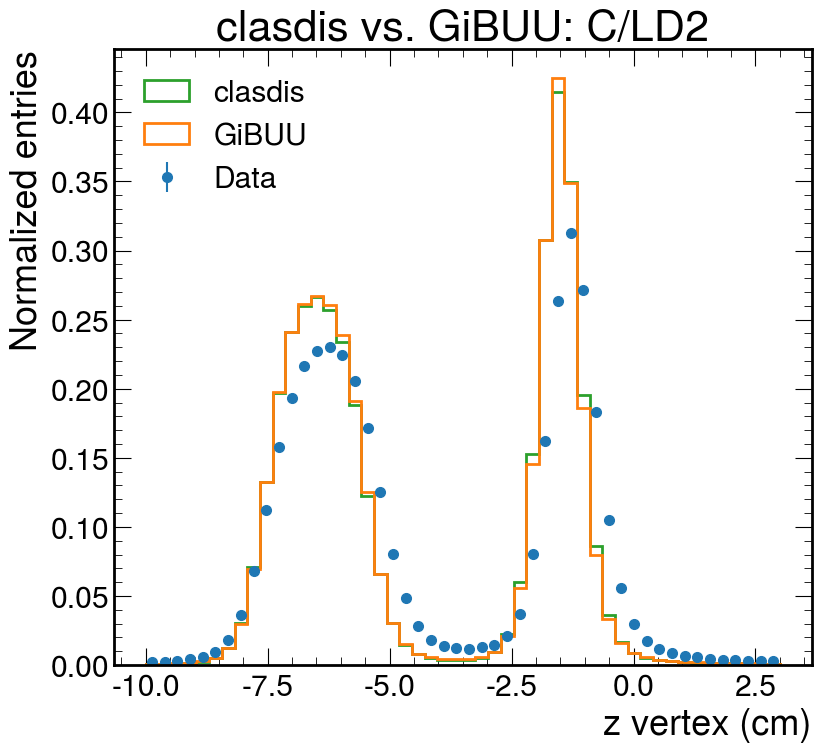

In [22]:
low_bin, high_bin, num_bins = -10, 3, 50

fig =  plt.figure(figsize=(9,8))

data_counts, data_bin_edges = np.histogram(
    branches_dict["data"]["v_z"],
    bins = num_bins,
    range = (low_bin, high_bin),
)
data_errors = np.sqrt(data_counts)

total_data_entries = np.sum(data_counts)
data_bin_widths = np.diff(data_bin_edges)
normalized_data_counts = data_counts / (total_data_entries * data_bin_widths)
normalized_data_errors = data_errors / (total_data_entries * data_bin_widths)
data_bin_centers = (data_bin_edges[:-1] + data_bin_edges[1:])/2
if include_data:
    plt.errorbar(
        data_bin_centers,
        normalized_data_counts,
        yerr = normalized_data_errors,
        fmt = 'o',
        color= '#1f77b4',
        label = "Data",
        markersize = 7,
    )
plt.hist(
    branches_dict["MC1"]["v_z"],
    weights = branches_dict["MC1"]["weight"],
    bins = num_bins,
    range=(low_bin, high_bin),
    density=True,
    label = MC1_name,
    histtype='step',
    color='#2ca02c',
    linewidth=2
)

plt.hist(
    branches_dict["MC2"]["v_z"],
    weights = branches_dict["MC2"]["weight"],
    bins = num_bins,
    range=(low_bin, high_bin),
    density=True,
    label = MC2_name,
    histtype='step',
    color='#ff7f0e',
    linewidth=2
)

if "v_z" in variables_to_unfold:
    plt.hist(
        branches_dict["MC2"]["v_z"],
        weights = step1_weights,
        bins = num_bins,
        range=(low_bin, high_bin),
        density=True,
        label="Reweighted Simulation",
        color='#2ca02c',
        alpha=.5,
    )

plt.xlabel("z vertex (cm)")
plt.ylabel("Normalized entries")
plt.legend(loc='upper left')
plt.title(plot_title)

[-7.06, -7.03, -0.707, -1.46, -2.26, ..., -6.15, -1.18, -1.68, -7.52, -7.91]
[1, 1, 0.75, 0.75, 0.75, 0.75, 0.75, 1, ..., 1, 1, 0.75, 1, 0.75, 0.75, 1, 1]
[-7.06, -7.03, -0.707, -1.46, -2.26, ..., -6.15, -1.18, -1.68, -7.52, -7.91]
[1, 1, 0.75, 0.75, 0.75, 0.75, 0.75, 1, ..., 1, 1, 0.75, 1, 0.75, 0.75, 1, 1]
[-7.06, -7.03, -0.707, -1.46, -2.26, ..., -6.15, -1.18, -1.68, -7.52, -7.91]
[1, 1, 0.75, 0.75, 0.75, 0.75, 0.75, 1, ..., 1, 1, 0.75, 1, 0.75, 0.75, 1, 1]
[-7.06, -7.03, -0.707, -1.46, -2.26, ..., -6.15, -1.18, -1.68, -7.52, -7.91]
[1, 1, 0.75, 0.75, 0.75, 0.75, 0.75, 1, ..., 1, 1, 0.75, 1, 0.75, 0.75, 1, 1]
[-7.06, -7.03, -0.707, -1.46, -2.26, ..., -6.15, -1.18, -1.68, -7.52, -7.91]
[1, 1, 0.75, 0.75, 0.75, 0.75, 0.75, 1, ..., 1, 1, 0.75, 1, 0.75, 0.75, 1, 1]
[-7.06, -7.03, -0.707, -1.46, -2.26, ..., -6.15, -1.18, -1.68, -7.52, -7.91]
[1, 1, 0.75, 0.75, 0.75, 0.75, 0.75, 1, ..., 1, 1, 0.75, 1, 0.75, 0.75, 1, 1]


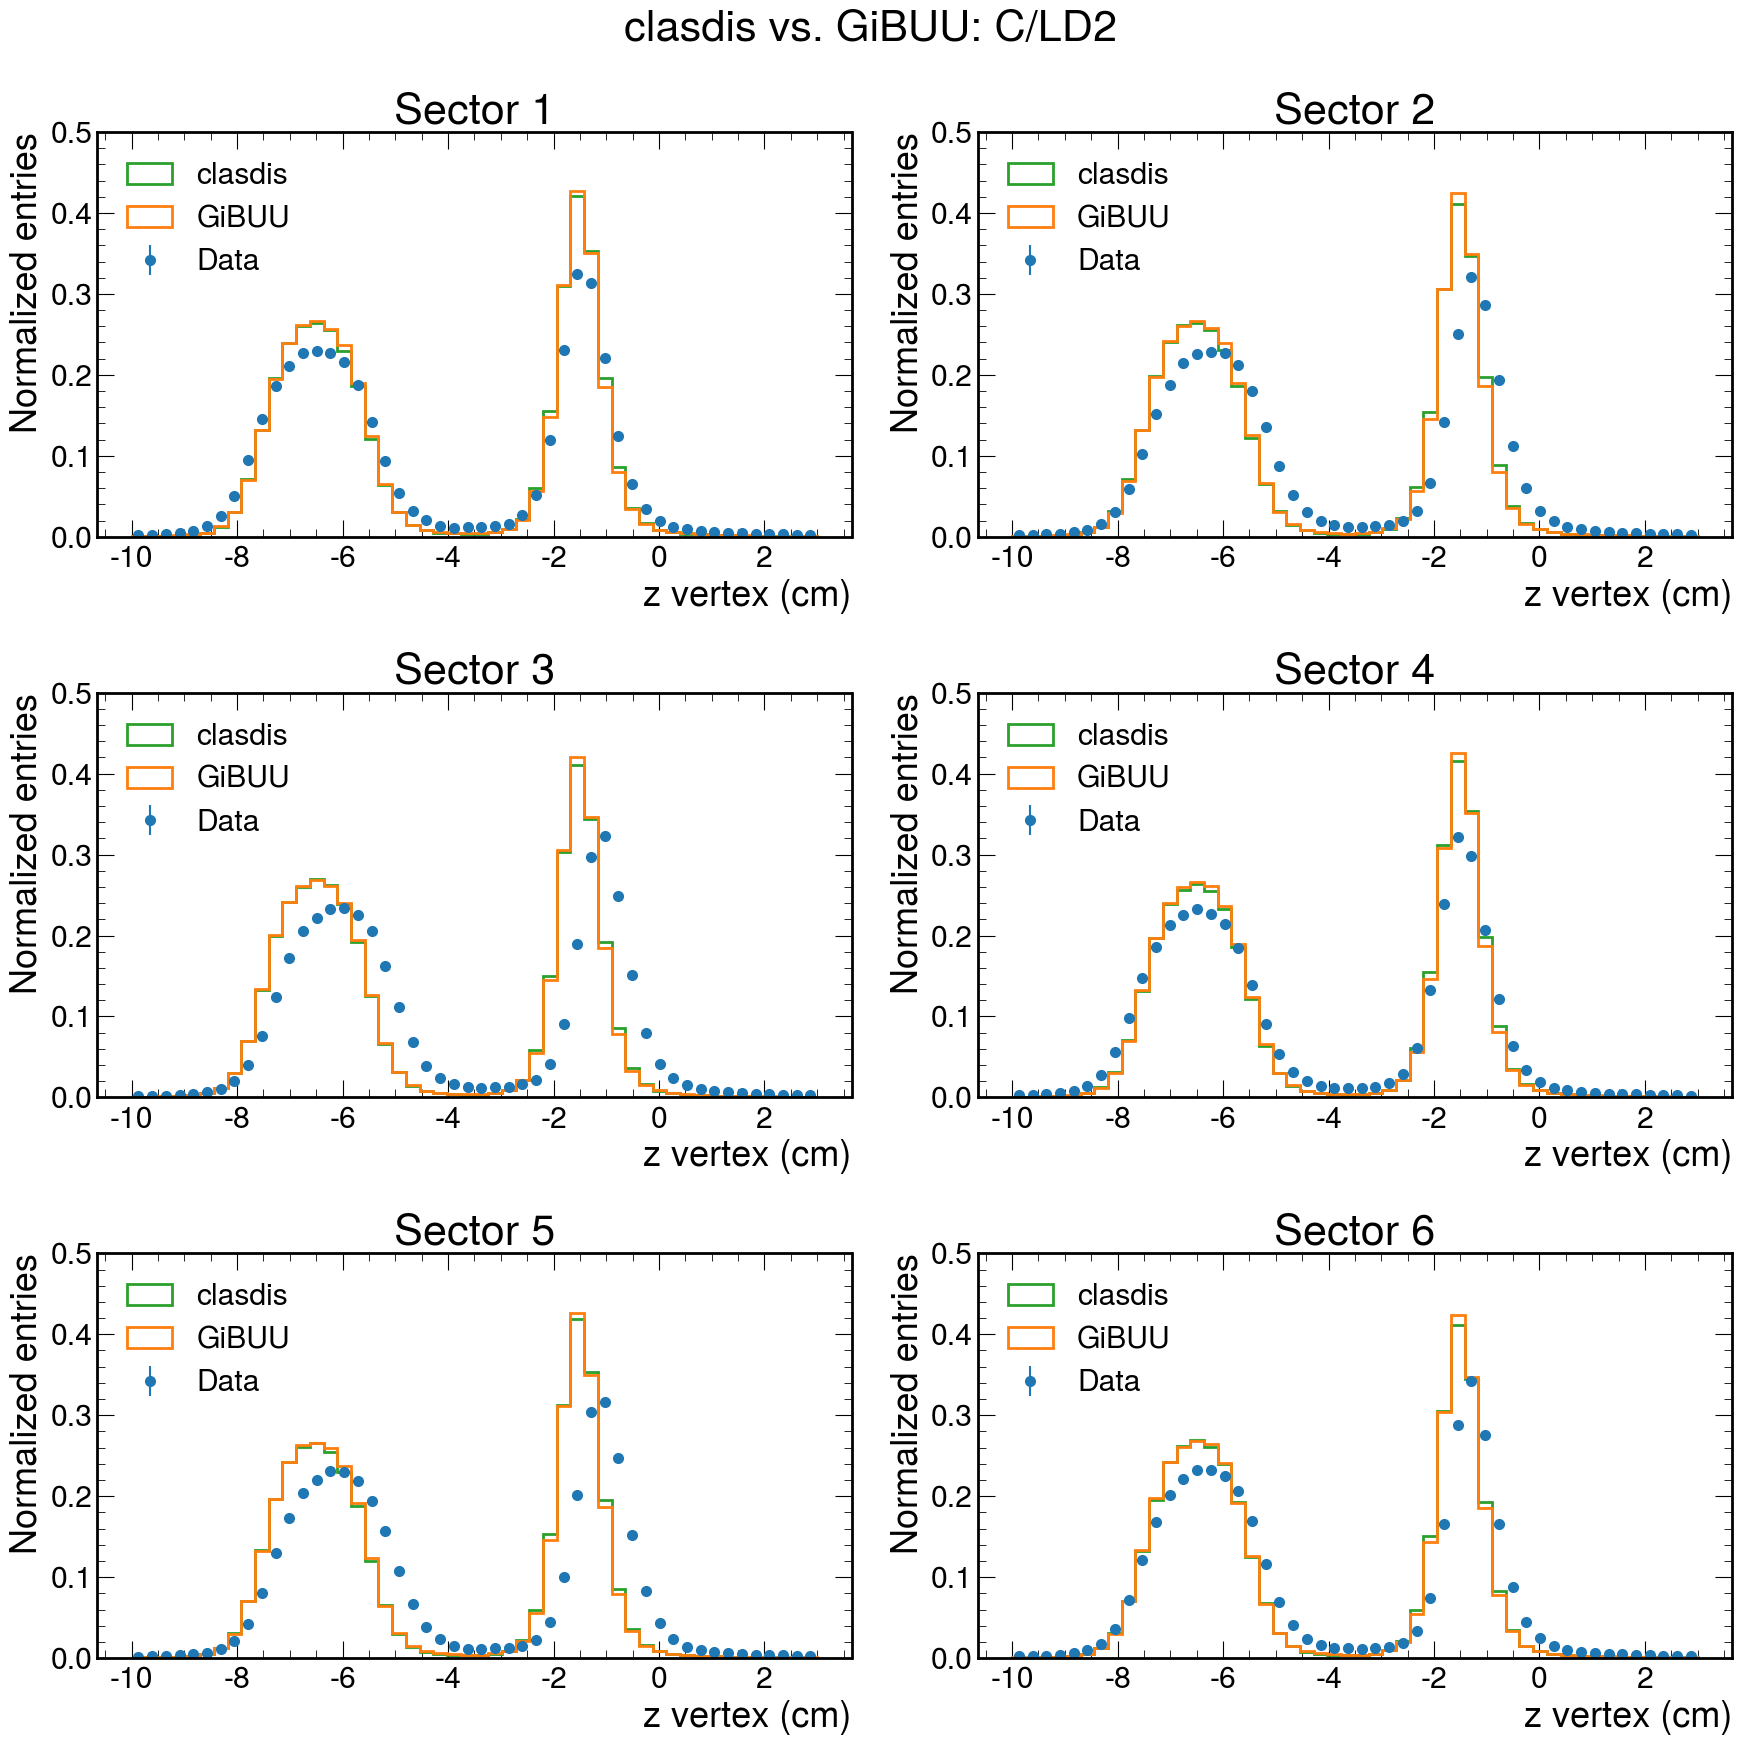

In [23]:
low_bin, high_bin, num_bins = -10, 3, 50

fig, axs = plt.subplots(3, 2, figsize=(18, 18))
axs = axs.flatten()
for sector in range(num_sectors):
    MC1_sector_cut = branches_dict["MC1"]["sector"]==(sector+1)
    MC2_sector_cut = branches_dict["MC2"]["sector"]==(sector+1)

    data_sector_cut = branches_dict["data"]["sector"]==(sector+1)
    data_counts, data_bin_edges = np.histogram(
        branches_dict["data"]["v_z"][data_sector_cut],
        bins = num_bins,
        range = (low_bin, high_bin),
    )
    data_errors = np.sqrt(data_counts)
    
    total_data_entries = np.sum(data_counts)
    data_bin_widths = np.diff(data_bin_edges)
    normalized_data_counts = data_counts / (total_data_entries * data_bin_widths)
    normalized_data_errors = data_errors / (total_data_entries * data_bin_widths)
    data_bin_centers = (data_bin_edges[:-1] + data_bin_edges[1:])/2

    if include_data:
        axs[sector].errorbar(
            data_bin_centers,
            normalized_data_counts,
            yerr = normalized_data_errors,
            fmt = 'o',
            color= '#1f77b4',
            label = "Data",
            markersize = 7,
    )
    axs[sector].hist(
        branches_dict["MC1"]["v_z"][MC1_sector_cut],
        weights = branches_dict["MC1"]["weight"][MC1_sector_cut],
        bins = num_bins,
        range=(low_bin, high_bin),
        density=True,
        label = MC1_name,
        histtype='step',
        color='#2ca02c',
        linewidth=2
    )

    print(branches_dict["MC2"]["v_z"])
    print(branches_dict["MC2"]["weight"])
    axs[sector].hist(
        branches_dict["MC2"]["v_z"][MC2_sector_cut],
        weights = branches_dict["MC2"]["weight"][MC2_sector_cut],
        bins = num_bins,
        range=(low_bin, high_bin),
        density=True,
        label = MC2_name,
        histtype='step',
        color='#ff7f0e',
        linewidth=2
    )
    # axs[sector].hist(
    #     branches_dict["MC2"]["v_z"][MC2_sector_cut],
    #     weights = step1_weights[MC2_sector_cut],
    #     bins = num_bins,
    #     range=(low_bin, high_bin),
    #     density=True,
    #     label="Reweighted Simulation",
    #     color='#2ca02c',
    #     alpha=.5,
    #     linewidth=2
    # )
    axs[sector].set_xlabel("z vertex (cm)")
    axs[sector].set_ylabel("Normalized entries")
    axs[sector].legend(loc='upper left')
    axs[sector].set_title(f"Sector {sector+1}")
    axs[sector].set_ylim(0,.5)
plt.suptitle(plot_title)

plt.tight_layout()

Text(0.5, 1.0, 'clasdis vs. GiBUU: C/LD2')

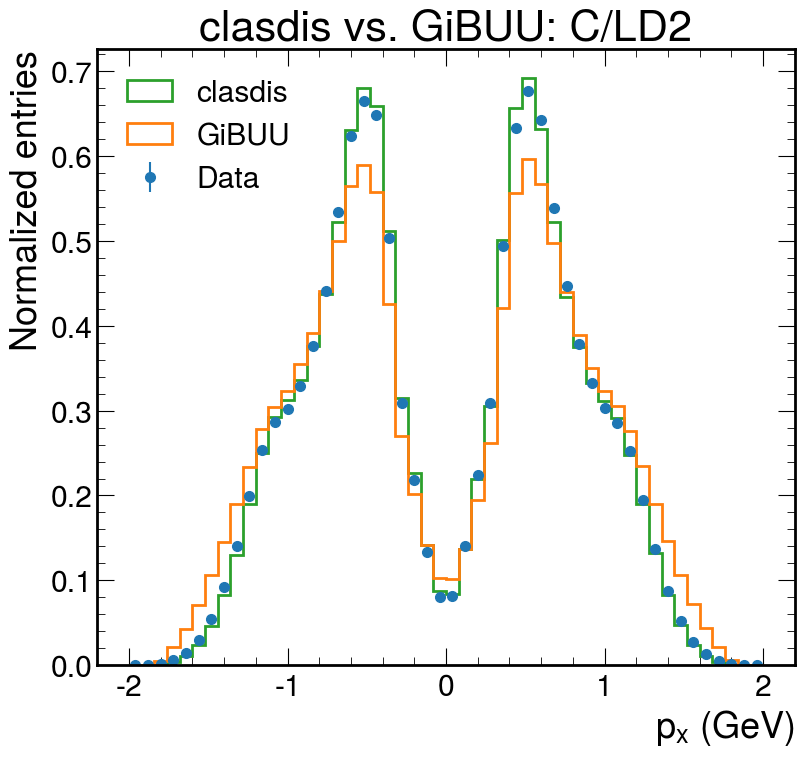

In [24]:
low_bin, high_bin, num_bins = -2, 2, 50


fig =  plt.figure(figsize=(9,8))

data_counts, data_bin_edges = np.histogram(
    branches_dict["data"]["p_x"],
    bins = num_bins,
    range = (low_bin, high_bin),
)
data_errors = np.sqrt(data_counts)

total_data_entries = np.sum(data_counts)
data_bin_widths = np.diff(data_bin_edges)
normalized_data_counts = data_counts / (total_data_entries * data_bin_widths)
normalized_data_errors = data_errors / (total_data_entries * data_bin_widths)
data_bin_centers = (data_bin_edges[:-1] + data_bin_edges[1:])/2
if include_data:
    plt.errorbar(
        data_bin_centers,
        normalized_data_counts,
        yerr = normalized_data_errors,
        fmt = 'o',
        color= '#1f77b4',
        label = "Data",
        markersize = 7,
    )
plt.hist(
    branches_dict["MC1"]["p_x"],
    weights = branches_dict["MC1"]["weight"],
    bins = num_bins,
    range=(low_bin, high_bin),
    density=True,
    label = MC1_name,
    histtype='step',
    color='#2ca02c',
    linewidth=2
)

plt.hist(
    branches_dict["MC2"]["p_x"],
    weights = branches_dict["MC2"]["weight"],
    bins = num_bins,
    range=(low_bin, high_bin),
    density=True,
    label = MC2_name,
    histtype='step',
    color='#ff7f0e',
    linewidth=2
)
if "p_x" in variables_to_unfold:
    plt.hist(
        branches_dict["MC2"]["p_x"],
        weights = step1_weights,
        bins = num_bins,
        range=(low_bin, high_bin),
        density=True,
        label="Reweighted Simulation",
        color='#2ca02c',
        alpha=.5,
    )
plt.xlabel("$p_x$ (GeV)")
plt.ylabel("Normalized entries")
plt.legend(loc='upper left')
plt.title(plot_title)

Text(0.5, 1.0, 'clasdis vs. GiBUU: C/LD2')

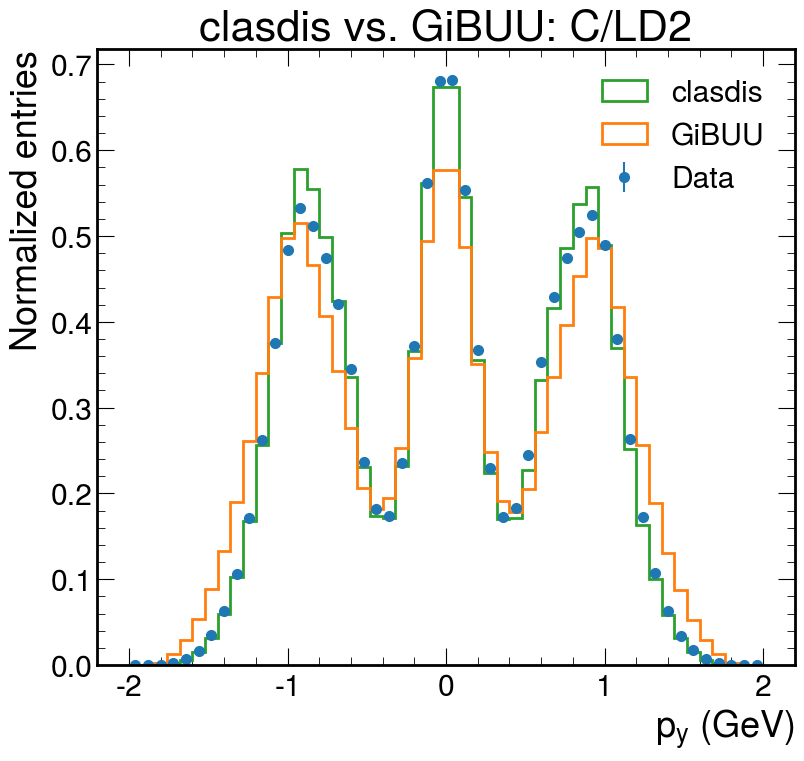

In [25]:
low_bin, high_bin, num_bins = -2, 2, 50

fig =  plt.figure(figsize=(9,8))

data_counts, data_bin_edges = np.histogram(
    branches_dict["data"]["p_y"],
    bins = num_bins,
    range = (low_bin, high_bin),
)
data_errors = np.sqrt(data_counts)

total_data_entries = np.sum(data_counts)
data_bin_widths = np.diff(data_bin_edges)
normalized_data_counts = data_counts / (total_data_entries * data_bin_widths)
normalized_data_errors = data_errors / (total_data_entries * data_bin_widths)
data_bin_centers = (data_bin_edges[:-1] + data_bin_edges[1:])/2
if include_data:
    plt.errorbar(
        data_bin_centers,
        normalized_data_counts,
        yerr = normalized_data_errors,
        fmt = 'o',
        color= '#1f77b4',
        label = "Data",
        markersize = 7,
    )
plt.hist(
    branches_dict["MC1"]["p_y"],
    weights = branches_dict["MC1"]["weight"],
    bins = num_bins,
    range=(low_bin, high_bin),
    density=True,
    label = MC1_name,
    histtype='step',
    color='#2ca02c',
    linewidth=2
)
plt.hist(
    branches_dict["MC2"]["p_y"],
    weights = branches_dict["MC2"]["weight"],
    bins = num_bins,
    range=(low_bin, high_bin),
    density=True,
    label = MC2_name,
    histtype='step',
    color='#ff7f0e',
    linewidth=2
)
if "p_y" in variables_to_unfold:
    plt.hist(
        branches_dict["MC2"]["p_y"],
        weights = step1_weights,
        bins = num_bins,
        range=(low_bin, high_bin),
        density=True,
        label="Reweighted Simulation",
        color='#2ca02c',
        alpha=.5,
    )
plt.xlabel("$p_y$ (GeV)")
plt.ylabel("Normalized entries")
plt.legend()
plt.title(plot_title)

Text(0.5, 1.0, 'clasdis vs. GiBUU: C/LD2')

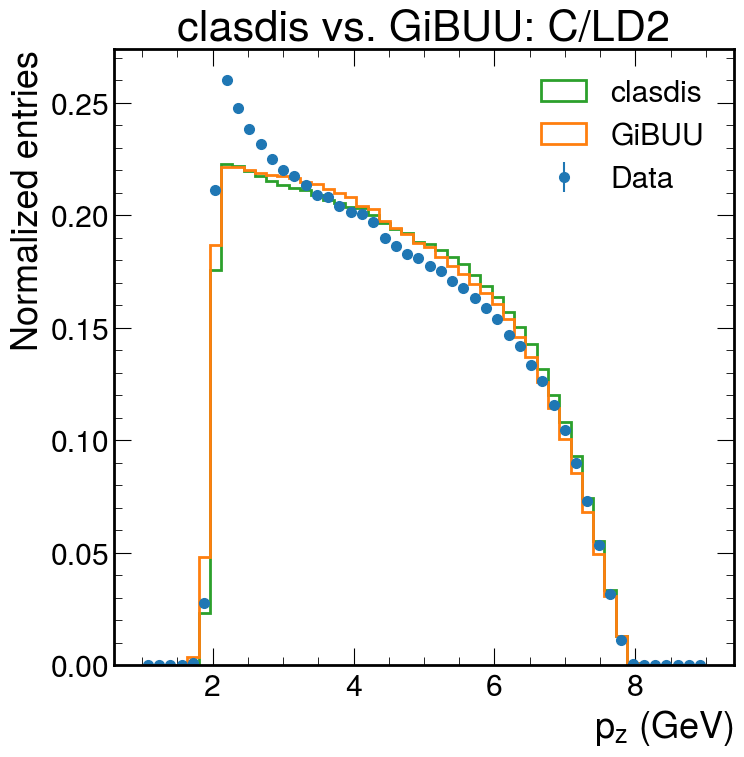

In [26]:
low_bin, high_bin, num_bins = 1, 9, 50


fig =  plt.figure(figsize=(8,8))

data_counts, data_bin_edges = np.histogram(
    branches_dict["data"]["p_z"],
    bins = num_bins,
    range = (low_bin, high_bin),
)
data_errors = np.sqrt(data_counts)

total_data_entries = np.sum(data_counts)
data_bin_widths = np.diff(data_bin_edges)
normalized_data_counts = data_counts / (total_data_entries * data_bin_widths)
normalized_data_errors = data_errors / (total_data_entries * data_bin_widths)
data_bin_centers = (data_bin_edges[:-1] + data_bin_edges[1:])/2
if include_data:
    plt.errorbar(
        data_bin_centers,
        normalized_data_counts,
        yerr = normalized_data_errors,
        fmt = 'o',
        color= '#1f77b4',
        label = "Data",
        markersize = 7,
    )
plt.hist(
    branches_dict["MC1"]["p_z"],
    weights = branches_dict["MC1"]["weight"],
    bins = num_bins,
    range=(low_bin, high_bin),
    density=True,
    label = MC1_name,
    histtype='step',
    color='#2ca02c',
    linewidth=2
)

plt.hist(
    branches_dict["MC2"]["p_z"],
    weights = branches_dict["MC2"]["weight"],
    bins = num_bins,
    range=(low_bin, high_bin),
    density=True,
    label = MC2_name,
    histtype='step',
    color='#ff7f0e',
    linewidth=2
)
if "p_z" in variables_to_unfold:
    plt.hist(
        branches_dict["MC2"]["p_z"],
        weights = step1_weights,
        bins = num_bins,
        range=(low_bin, high_bin),
        density=True,
        label="Reweighted Simulation",
        color='#2ca02c',
        alpha=.5,
    )
plt.xlabel("$p_z$ (GeV)")
plt.ylabel("Normalized entries")
plt.legend()
plt.title(plot_title)

Text(0.5, 1.0, 'clasdis vs. GiBUU: C/LD2')

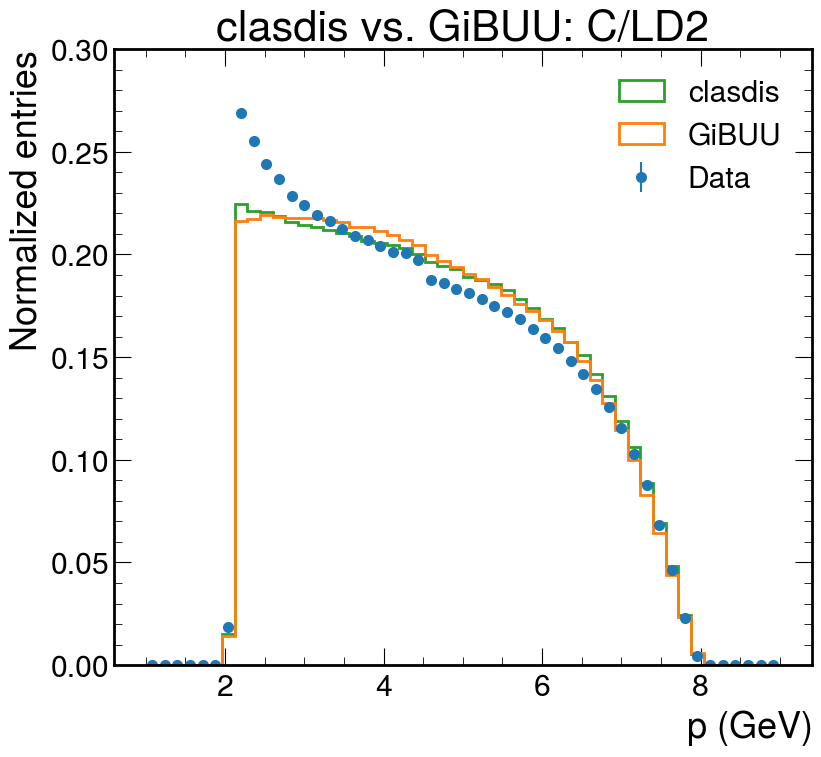

In [27]:
low_bin, high_bin, num_bins = 1, 9, 50


fig =  plt.figure(figsize=(9,8))

data_counts, data_bin_edges = np.histogram(
    branches_dict["data"]["p"],
    bins = num_bins,
    range = (low_bin, high_bin),
)
data_errors = np.sqrt(data_counts)

total_data_entries = np.sum(data_counts)
data_bin_widths = np.diff(data_bin_edges)
normalized_data_counts = data_counts / (total_data_entries * data_bin_widths)
normalized_data_errors = data_errors / (total_data_entries * data_bin_widths)
data_bin_centers = (data_bin_edges[:-1] + data_bin_edges[1:])/2
if include_data:
    plt.errorbar(
        data_bin_centers,
        normalized_data_counts,
        yerr = normalized_data_errors,
        fmt = 'o',
        color= '#1f77b4',
        label = "Data",
        markersize = 7,
    )
plt.hist(
    branches_dict["MC1"]["p"],
    weights = branches_dict["MC1"]["weight"],
    bins = num_bins,
    range=(low_bin, high_bin),
    density=True,
    label = MC1_name,
    histtype='step',
    color='#2ca02c',
    linewidth=2
)
plt.hist(
    branches_dict["MC2"]["p"],
    weights = branches_dict["MC2"]["weight"],
    bins = num_bins,
    range=(low_bin, high_bin),
    density=True,
    label = MC2_name,
    histtype='step',
    color='#ff7f0e',
    linewidth=2
)
if "p" in variables_to_unfold:
    plt.hist(
        branches_dict["MC2"]["p"],
        weights = step1_weights,
        bins = num_bins,
        range=(low_bin, high_bin),
        density=True,
        label="Reweighted Simulation",
        color='#2ca02c',
        alpha=.5,
    )
plt.xlabel("$p$ (GeV)")
plt.ylabel("Normalized entries")
plt.legend(loc='upper right')
plt.ylim(0,.3)
plt.title(plot_title)

Text(0.5, 1.0, 'clasdis vs. GiBUU: C/LD2')

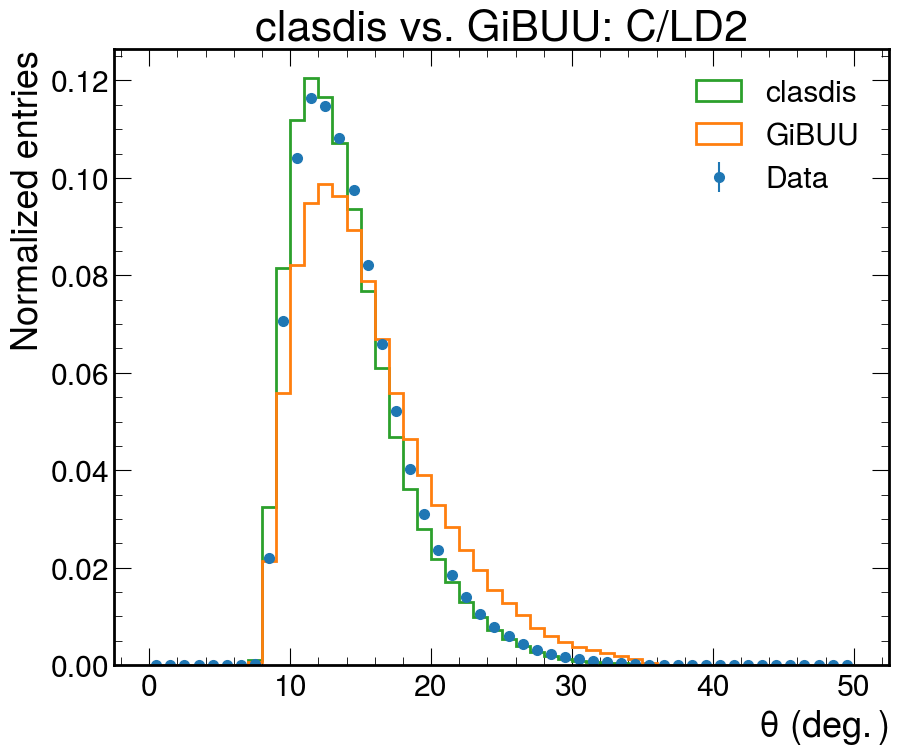

In [28]:
low_bin, high_bin, num_bins = 0, 50, 50


fig =  plt.figure(figsize=(10,8))

data_counts, data_bin_edges = np.histogram(
    branches_dict["data"]["theta_degrees"],
    bins = num_bins,
    range = (low_bin, high_bin),
)
data_errors = np.sqrt(data_counts)

total_data_entries = np.sum(data_counts)
data_bin_widths = np.diff(data_bin_edges)
normalized_data_counts = data_counts / (total_data_entries * data_bin_widths)
normalized_data_errors = data_errors / (total_data_entries * data_bin_widths)
data_bin_centers = (data_bin_edges[:-1] + data_bin_edges[1:])/2
if include_data:
    plt.errorbar(
        data_bin_centers,
        normalized_data_counts,
        yerr = normalized_data_errors,
        fmt = 'o',
        color= '#1f77b4',
        label = "Data",
        markersize = 7,
    )
plt.hist(
    branches_dict["MC1"]["theta_degrees"],
    weights = branches_dict["MC1"]["weight"],
    bins = num_bins,
    range=(low_bin, high_bin),
    density=True,
    label = MC1_name,
    histtype='step',
    color='#2ca02c',
    linewidth=2
)
plt.hist(
    branches_dict["MC2"]["theta_degrees"],
    weights = branches_dict["MC2"]["weight"],
    bins = num_bins,
    range=(low_bin, high_bin),
    density=True,
    label = MC2_name,
    histtype='step',
    color='#ff7f0e',
    linewidth=2,
)
if "theta_degrees" in variables_to_unfold:
    plt.hist(
        branches_dict["MC2"]["theta_degrees"],
        weights = step1_weights,
        bins = num_bins,
        range=(low_bin, high_bin),
        density=True,
        label="Reweighted Simulation",
        color='#2ca02c',
        alpha=.5,
        linewidth=2,
    )
plt.xlabel("$\\theta ~(deg.)$")
plt.ylabel("Normalized entries")
plt.legend()
plt.title(plot_title)

Text(0.5, 1.0, 'clasdis vs. GiBUU: C/LD2')

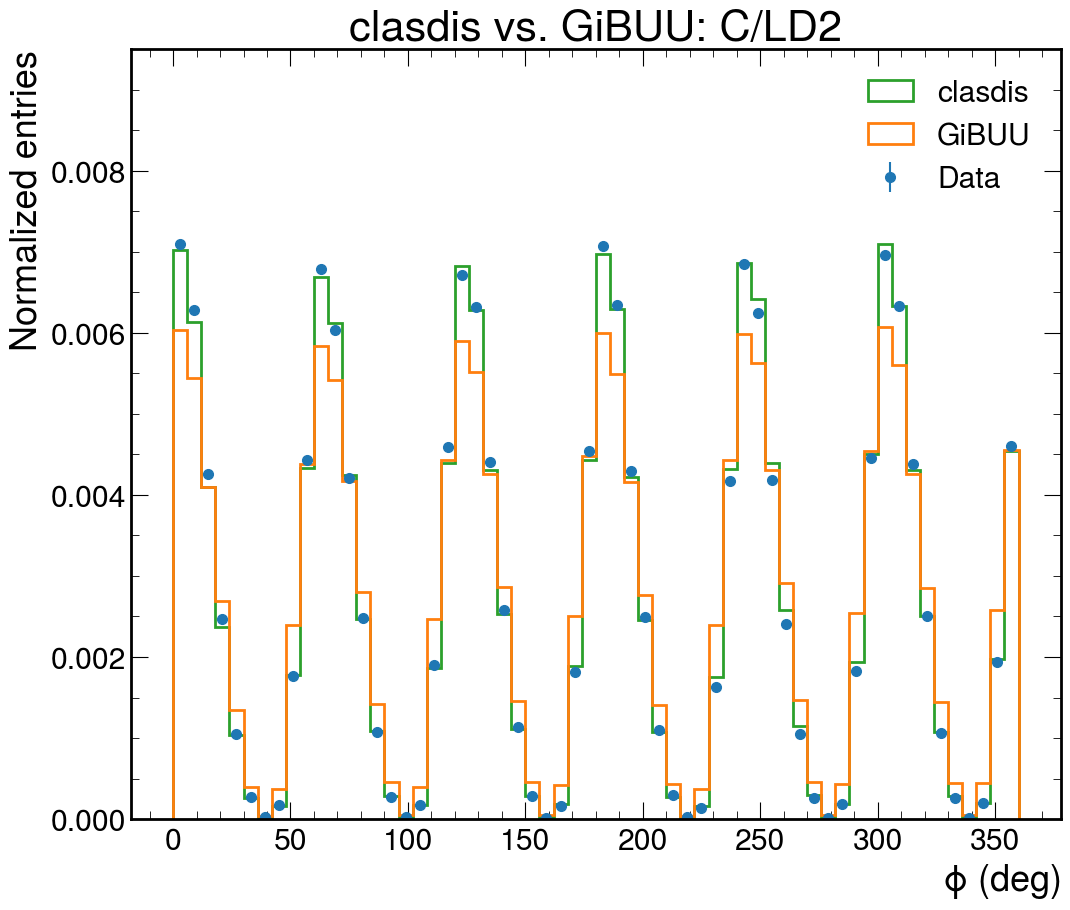

In [29]:
low_bin, high_bin, num_bins = 0, 360, 60


fig =  plt.figure(figsize=(12,10))

data_counts, data_bin_edges = np.histogram(
    branches_dict["data"]["phi_degrees"],
    bins = num_bins,
    range = (low_bin, high_bin),
)
data_errors = np.sqrt(data_counts)

total_data_entries = np.sum(data_counts)
data_bin_widths = np.diff(data_bin_edges)
normalized_data_counts = data_counts / (total_data_entries * data_bin_widths)
normalized_data_errors = data_errors / (total_data_entries * data_bin_widths)
data_bin_centers = (data_bin_edges[:-1] + data_bin_edges[1:])/2
if include_data:
    plt.errorbar(
        data_bin_centers,
        normalized_data_counts,
        yerr = normalized_data_errors,
        fmt = 'o',
        color= '#1f77b4',
        label = "Data",
        markersize = 7,
    )
plt.hist(
    branches_dict["MC1"]["phi_degrees"],
    weights = branches_dict["MC1"]["weight"],
    bins = num_bins,
    range=(low_bin, high_bin),
    density=True,
    label = MC1_name,
    histtype='step',
    color='#2ca02c',
    linewidth=2
)
plt.hist(
    branches_dict["MC2"]["phi_degrees"],
    weights = branches_dict["MC2"]["weight"],
    bins = num_bins,
    range=(low_bin, high_bin),
    density=True,
    label = MC2_name,
    histtype='step',
    color='#ff7f0e',
    linewidth=2,
)
if "phi_degrees" in variables_to_unfold:
    plt.hist(
        branches_dict["MC2"]["phi_degrees"],
        weights = step1_weights,
        bins = num_bins,
        range=(low_bin, high_bin),
        density=True,
        label="Reweighted Simulation",
        color='#2ca02c',
        alpha=.5,
        linewidth=2,
    )
plt.xlabel("$\phi ~(deg)$")
plt.ylabel("Normalized entries")
plt.legend()
plt.ylim(0, .0095)
plt.title(plot_title)

Text(0.5, 1.01, 'clasdis vs. GiBUU: C/LD2')

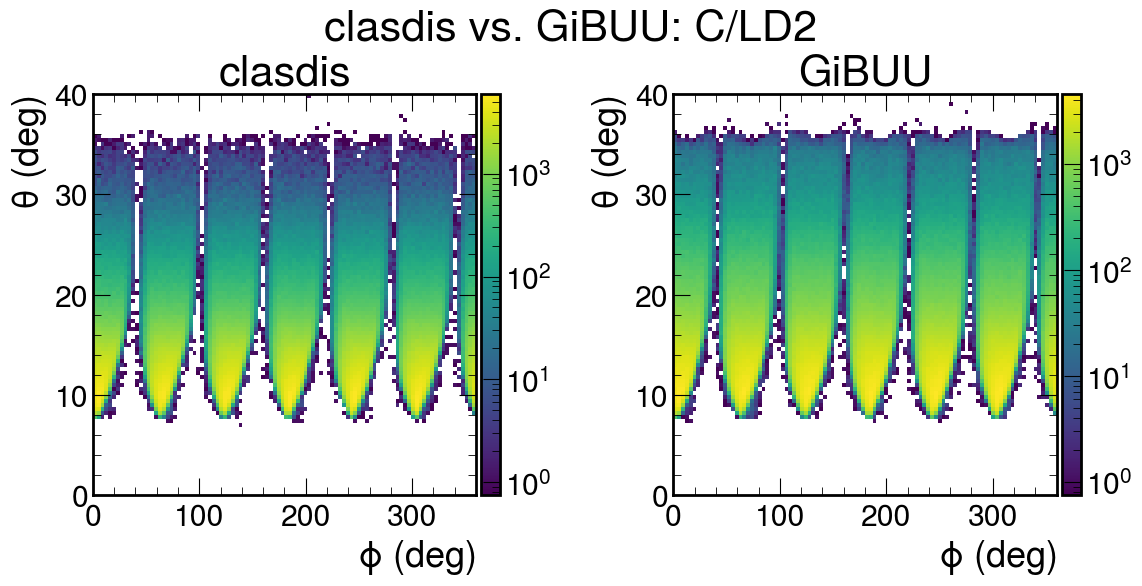

In [30]:
low_bin, high_bin, num_bins = (0, 360), (0,40), (100, 100)
fig, axs = plt.subplots(1, 2, figsize=(12,6))
_, _, _, mesh = axs[0].hist2d(
    np.array(branches_dict["MC1"]["phi_degrees"]),
    np.array(branches_dict["MC1"]["theta_degrees"]),
    weights = np.array(branches_dict["MC1"]["weight"]),
    bins = num_bins,
    range=(low_bin, high_bin),
    norm=mcolors.LogNorm(),
)
axs[0].set_ylabel("$\\theta$ (deg)")
axs[0].set_xlabel("$\phi$ (deg)")
axs[0].set_title(f"{MC1_name}")
divider = make_axes_locatable(axs[0])
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(mesh, cax=cax)

_, _, _, mesh = axs[1].hist2d(
    np.array(branches_dict["MC2"]["phi_degrees"]),
    np.array(branches_dict["MC2"]["theta_degrees"]),
    weights = np.array(branches_dict["MC2"]["weight"]),
    bins = num_bins,
    range=(low_bin, high_bin),
    norm=mcolors.LogNorm(),
)
axs[1].set_ylabel("$\\theta$ (deg)")
axs[1].set_xlabel("$\phi$ (deg)")
axs[1].set_title(f"{MC2_name}")
divider = make_axes_locatable(axs[1])
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(mesh, cax=cax)
plt.tight_layout()
plt.suptitle(plot_title, y = 1.01)

Text(0.5, 1.01, 'clasdis vs. GiBUU: C/LD2')

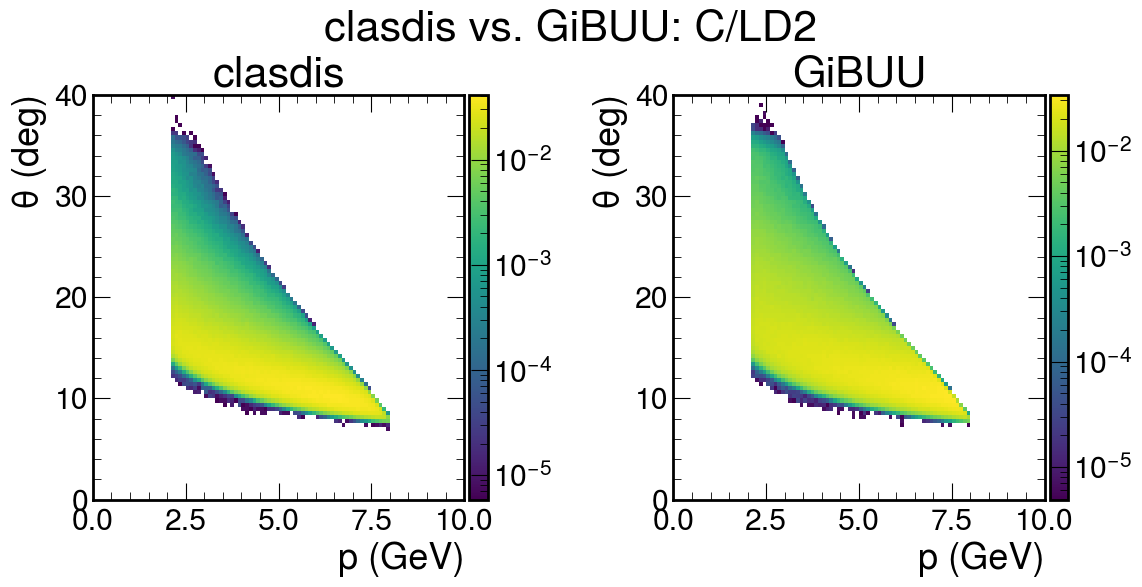

In [31]:
low_bin, high_bin, num_bins = (0, 10), (0,40), (100, 100)
fig, axs = plt.subplots(1, 2, figsize=(12,6))
_, _, _, mesh = axs[0].hist2d(
    np.array(branches_dict["MC1"]["p"]),
    np.array(branches_dict["MC1"]["theta"])*180/np.pi,
    weights = np.array(branches_dict["MC1"]["weight"]),
    bins = num_bins,
    range=(low_bin, high_bin),
    norm=mcolors.LogNorm(),
    density=True,
)
axs[0].set_ylabel("$\\theta$ (deg)")
axs[0].set_xlabel("p (GeV)")
axs[0].set_title(f"{MC1_name}")
divider = make_axes_locatable(axs[0])
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(mesh, cax=cax)

_, _, _, mesh = axs[1].hist2d(
    np.array(branches_dict["MC2"]["p"]),
    np.array(branches_dict["MC2"]["theta"])*180/np.pi,
    weights = np.array(branches_dict["MC2"]["weight"]),
    bins = num_bins,
    range=(low_bin, high_bin),
    norm=mcolors.LogNorm(),
    density=True,
)
axs[1].set_ylabel("$\\theta$ (deg)")
axs[1].set_xlabel("p (GeV)")
axs[1].set_title(f"{MC2_name}")
divider = make_axes_locatable(axs[1])
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(mesh, cax=cax)
plt.tight_layout()
plt.suptitle(plot_title, y = 1.01)

Text(0.5, 1.0, 'clasdis vs. GiBUU: C/LD2')

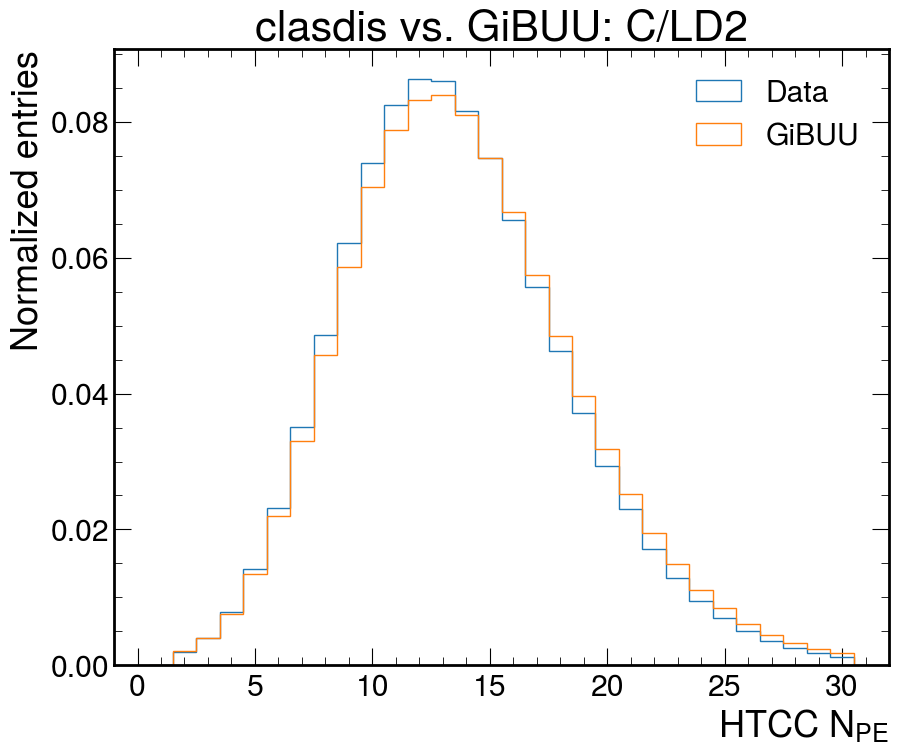

In [32]:
low_bin, high_bin, num_bins = 0.5, 30.5, 30

fig =  plt.figure(figsize=(10,8))
plt.hist(
    branches_dict["MC1"]["Nphe_HTCC"],
    weights = np.array(branches_dict["MC1"]["weight"]),
    bins = num_bins,
    range=(low_bin, high_bin),
    density=True,
    label="Data",
    histtype='step',
    color='#1f77b4',
)
plt.hist(
    branches_dict["MC2"]["Nphe_HTCC"],
    weights = branches_dict["MC2"]["weight"],
    bins = num_bins,
    range=(low_bin, high_bin),
    density=True,
    label = MC2_name,
    histtype='step',
    color='#ff7f0e',
)
plt.xlabel("HTCC $N_{PE}$")
plt.ylabel("Normalized entries")
plt.legend()
plt.title(plot_title)

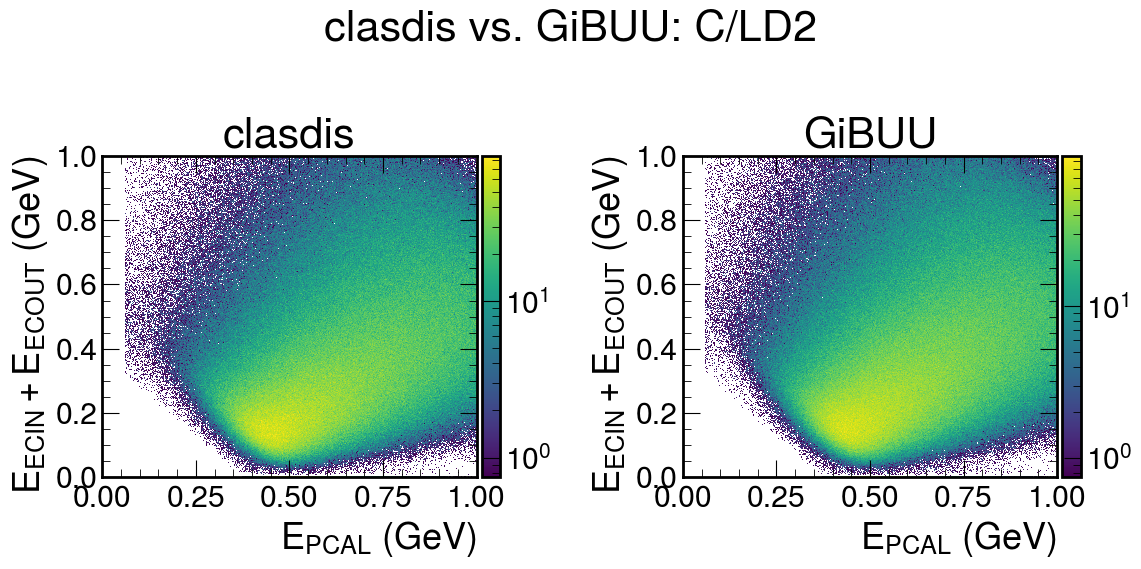

In [33]:
low_bin, high_bin, num_bins = (0, 1), (0,1), (500,500)
fig, axs = plt.subplots(1, 2, figsize=(12,6))
_, _, _, mesh = axs[0].hist2d(
    np.array(branches_dict["MC1"]["E_PCAL"]),
    np.array(branches_dict["MC1"]["E_ECIN"]+branches_dict["MC1"]["E_ECOUT"]),
    weights = np.array(branches_dict["MC1"]["weight"]),
    bins = num_bins,
    range=(low_bin, high_bin),
    norm=mcolors.LogNorm(),
)
axs[0].set_xlabel("$E_{PCAL}$ (GeV)")
axs[0].set_ylabel("$E_{ECIN}+E_{ECOUT}$ (GeV)")
axs[0].set_title(f"{MC1_name}")
divider = make_axes_locatable(axs[0])
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(mesh, cax=cax)

_, _, _, mesh = axs[1].hist2d(
    np.array(branches_dict["MC2"]["E_PCAL"]),
    np.array(branches_dict["MC2"]["E_ECIN"]+branches_dict["MC2"]["E_ECOUT"]),
    weights = np.array(branches_dict["MC2"]["weight"]),
    bins = num_bins,
    range=(low_bin, high_bin),
    norm=mcolors.LogNorm(),
)
axs[1].set_xlabel("$E_{PCAL}$ (GeV)")
axs[1].set_ylabel("$E_{ECIN}+E_{ECOUT}$ (GeV)")
axs[1].set_title(f"{MC2_name}")
divider = make_axes_locatable(axs[1])
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(mesh, cax=cax)
plt.suptitle(plot_title)

plt.tight_layout()

In [ ]:
low_bin, high_bin, num_bins = (0, .2), (0,.25), (100, 100)
fig, axs = plt.subplots(1, 2, figsize=(12,6))
_, _, _, mesh = axs[0].hist2d(
    np.array(branches_dict["MC1"]["E_ECIN"]/branches_dict["MC1"]["p"]),
    np.array(branches_dict["MC1"]["E_PCAL"]/branches_dict["MC1"]["p"]),
    weights = np.array(branches_dict["MC1"]["weight"]),
    bins = num_bins,
    range=(low_bin, high_bin),
    norm=mcolors.LogNorm(),
)
axs[0].set_ylabel("$E_{PCAL}$/p")
axs[0].set_xlabel("$E_{ECIN}$/p")
axs[0].set_title(f"{MC1_name}")
divider = make_axes_locatable(axs[0])
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(mesh, cax=cax)

_, _, _, mesh = axs[1].hist2d(
    np.array(branches_dict["MC2"]["E_ECIN"]/branches_dict["MC2"]["p"]),
    np.array(branches_dict["MC2"]["E_PCAL"]/branches_dict["MC2"]["p"]),
    weights = np.array(branches_dict["MC2"]["weight"]),
    bins = num_bins,
    range=(low_bin, high_bin),
    norm=mcolors.LogNorm(),
)
axs[1].set_xlabel("$E_{PCAL}$ (GeV)")
axs[1].set_ylabel("$E_{ECIN}+E_{ECOUT}$ (GeV)")
axs[1].set_title(f"{MC2_name}")
divider = make_axes_locatable(axs[1])
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(mesh, cax=cax)
plt.suptitle(plot_title)

plt.tight_layout()

In [ ]:
low_bin, high_bin, num_bins = (0, 2), (0,.35), (100, 100)
fig, axs = plt.subplots(1, 2, figsize=(12,6))
_, _, _, mesh = axs[0].hist2d(
    np.array(branches_dict["MC1"]["E_PCAL"]),
    np.array(branches_dict["MC1"]["E_ECIN"]+branches_dict["MC1"]["E_ECOUT"]+branches_dict["MC1"]["E_PCAL"])/np.array(branches_dict["MC1"]["p"]),
    weights = np.array(branches_dict["MC1"]["weight"]),
    bins = num_bins,
    range=(low_bin, high_bin),
    norm=mcolors.LogNorm(),
)
axs[0].set_ylabel("SF")
axs[0].set_xlabel("$E_{PCAL}$ (GeV)")
axs[0].set_title(f"{MC1_name}")
divider = make_axes_locatable(axs[0])
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(mesh, cax=cax)

_, _, _, mesh = axs[1].hist2d(
    np.array(branches_dict["MC2"]["E_PCAL"]),
    np.array(branches_dict["MC2"]["E_ECIN"]+branches_dict["MC2"]["E_ECOUT"]+branches_dict["MC2"]["E_PCAL"])/np.array(branches_dict["MC2"]["p"]),
    weights = np.array(branches_dict["MC2"]["weight"]),
    bins = num_bins,
    range=(low_bin, high_bin),
    norm=mcolors.LogNorm(),
)
axs[1].set_ylabel("SF")
axs[1].set_xlabel("$E_{PCAL}$ (GeV)")
axs[1].set_title(f"{MC2_name}")
divider = make_axes_locatable(axs[1])
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(mesh, cax=cax)
plt.suptitle(plot_title)

plt.tight_layout()

In [ ]:
low_bin, high_bin, num_bins = (0, 10), (0,.35), (100, 100)
fig, axs = plt.subplots(1, 2, figsize=(12,6))
_, _, _, mesh = axs[0].hist2d(
    np.array(branches_dict["MC1"]["p"]),
    np.array(branches_dict["MC1"]["E_ECIN"]+branches_dict["MC1"]["E_ECOUT"]+branches_dict["MC1"]["E_PCAL"])/np.array(branches_dict["MC1"]["p"]),
    weights = np.array(branches_dict["MC1"]["weight"]),
    bins = num_bins,
    range=(low_bin, high_bin),
    norm=mcolors.LogNorm(),
)
axs[0].set_ylabel("SF")
axs[0].set_xlabel("p (GeV)")
axs[0].set_title(f"{MC1_name}")
divider = make_axes_locatable(axs[0])
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(mesh, cax=cax)

_, _, _, mesh = axs[1].hist2d(
    np.array(branches_dict["MC2"]["p"]),
    np.array(branches_dict["MC2"]["E_ECIN"]+branches_dict["MC2"]["E_ECOUT"]+branches_dict["MC2"]["E_PCAL"])/np.array(branches_dict["MC2"]["p"]),
    weights = np.array(branches_dict["MC2"]["weight"]),
    bins = num_bins,
    range=(low_bin, high_bin),
    norm=mcolors.LogNorm(),
)
axs[1].set_ylabel("SF")
axs[1].set_xlabel("p (GeV)")
axs[1].set_title(f"{MC2_name}")
divider = make_axes_locatable(axs[1])
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(mesh, cax=cax)
plt.suptitle(plot_title)

plt.tight_layout()

In [ ]:
low_bin, high_bin, num_bins = (0, 1), (0, 12), (100, 100)
fig, axs = plt.subplots(1, 2, figsize=(12,6))
_, _, _, mesh = axs[0].hist2d(
    np.array(branches_dict["MC1"]["x"]),
    np.array(branches_dict["MC1"]["Q2"]),
    weights = np.array(branches_dict["MC1"]["weight"]),
    bins = num_bins,
    range=(low_bin, high_bin),
    norm=mcolors.LogNorm(),
)
axs[0].set_ylabel("$Q^2~(GeV^2)$")
axs[0].set_xlabel("x")
axs[0].set_title(f"{MC1_name}")
divider = make_axes_locatable(axs[0])
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(mesh, cax=cax)

_, _, _, mesh = axs[1].hist2d(
    np.array(branches_dict["MC2"]["x"]),
    np.array(branches_dict["MC2"]["Q2"]),
    weights = np.array(branches_dict["MC2"]["weight"]),
    bins = num_bins,
    range=(low_bin, high_bin),
    norm=mcolors.LogNorm(),
)
axs[1].set_ylabel("$Q^2~(GeV^2)$")
axs[1].set_xlabel("x")
axs[1].set_title(f"{MC2_name}")
divider = make_axes_locatable(axs[1])
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(mesh, cax=cax)
plt.tight_layout()
plt.suptitle(plot_title, y = 1.01)


In [ ]:
low_bin, high_bin, num_bins = (0, 30), (0,.35), (100, 100)
fig, axs = plt.subplots(1, 2, figsize=(12,6))
_, _, _, mesh = axs[0].hist2d(
    np.array(branches_dict["MC1"]["PCAL_V"]),
    np.array(branches_dict["MC1"]["E_ECIN"]+branches_dict["MC1"]["E_ECOUT"]+branches_dict["MC1"]["E_PCAL"])/np.array(branches_dict["MC1"]["p"]),
    weights = np.array(branches_dict["MC1"]["weight"]),
    bins = num_bins,
    range=(low_bin, high_bin),
    norm=mcolors.LogNorm(),
)
axs[0].set_ylabel("SF")
axs[0].set_xlabel("PCAL V (cm)")
axs[0].set_title(f"{MC1_name}")
divider = make_axes_locatable(axs[0])
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(mesh, cax=cax)

_, _, _, mesh = axs[1].hist2d(
    np.array(branches_dict["MC2"]["PCAL_V"]),
    np.array(branches_dict["MC2"]["E_ECIN"]+branches_dict["MC2"]["E_ECOUT"]+branches_dict["MC2"]["E_PCAL"])/np.array(branches_dict["MC2"]["p"]),
    weights = np.array(branches_dict["MC2"]["weight"]),
    bins = num_bins,
    range=(low_bin, high_bin),
    norm=mcolors.LogNorm(),
)
axs[1].set_ylabel("SF")
axs[1].set_xlabel("PCAL V (cm)")
axs[1].set_title(f"{MC2_name}")
divider = make_axes_locatable(axs[1])
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(mesh, cax=cax)
plt.suptitle(plot_title)

plt.tight_layout()

In [ ]:
low_bin, high_bin, num_bins = (0, 30), (0,.35), (100, 100)
fig, axs = plt.subplots(1, 2, figsize=(12,6))
_, _, _, mesh = axs[0].hist2d(
    np.array(branches_dict["MC1"]["PCAL_W"]),
    np.array(branches_dict["MC1"]["E_ECIN"]+branches_dict["MC1"]["E_ECOUT"]+branches_dict["MC1"]["E_PCAL"])/np.array(branches_dict["MC1"]["p"]),
    weights = np.array(branches_dict["MC1"]["weight"]),
    bins = num_bins,
    range=(low_bin, high_bin),
    norm=mcolors.LogNorm(),
)
axs[0].set_ylabel("SF")
axs[0].set_xlabel("PCAL W (cm)")
axs[0].set_title(f"{MC1_name}")
divider = make_axes_locatable(axs[0])
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(mesh, cax=cax)

_, _, _, mesh = axs[1].hist2d(
    np.array(branches_dict["MC2"]["PCAL_W"]),
    np.array(branches_dict["MC2"]["E_ECIN"]+branches_dict["MC2"]["E_ECOUT"]+branches_dict["MC2"]["E_PCAL"])/np.array(branches_dict["MC2"]["p"]),
    weights = np.array(branches_dict["MC2"]["weight"]),
    bins = num_bins,
    range=(low_bin, high_bin),
    norm=mcolors.LogNorm(),
)
axs[1].set_ylabel("SF")
axs[1].set_xlabel("PCAL W (cm)")
axs[1].set_title(f"{MC2_name}")
divider = make_axes_locatable(axs[1])
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(mesh, cax=cax)
plt.suptitle(plot_title)

plt.tight_layout()

In [ ]:
low_bin, high_bin, num_bins = (0, 30), (0,.35), (100, 100)
fig, axs = plt.subplots(1, 2, figsize=(12,6))
_, _, _, mesh = axs[0].hist2d(
    np.array(branches_dict["MC1"]["PCAL_U"]),
    np.array(branches_dict["MC1"]["E_ECIN"]+branches_dict["MC1"]["E_ECOUT"]+branches_dict["MC1"]["E_PCAL"])/np.array(branches_dict["MC1"]["p"]),
    weights = np.array(branches_dict["MC1"]["weight"]),
    bins = num_bins,
    range=(low_bin, high_bin),
    norm=mcolors.LogNorm(),
)
axs[0].set_ylabel("SF")
axs[0].set_xlabel("PCAL U (cm)")
axs[0].set_title(f"{MC1_name}")
divider = make_axes_locatable(axs[0])
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(mesh, cax=cax)

_, _, _, mesh = axs[1].hist2d(
    np.array(branches_dict["MC2"]["PCAL_U"]),
    np.array(branches_dict["MC2"]["E_ECIN"]+branches_dict["MC2"]["E_ECOUT"]+branches_dict["MC2"]["E_PCAL"])/np.array(branches_dict["MC2"]["p"]),
    weights = np.array(branches_dict["MC2"]["weight"]),
    bins = num_bins,
    range=(low_bin, high_bin),
    norm=mcolors.LogNorm(),
)
axs[1].set_ylabel("SF")
axs[1].set_xlabel("PCAL U (cm)")
axs[1].set_title(f"{MC2_name}")
divider = make_axes_locatable(axs[1])
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(mesh, cax=cax)
plt.suptitle(plot_title)


plt.tight_layout()

In [ ]:
PCAL_data_cut = (branches_dict["MC1"]["PCAL_W"] >= 14) & (branches_dict["MC1"]["PCAL_V"] >= 14)
PCAL_sim_cut = (branches_dict["MC2"]["PCAL_W"] >= 14) & (branches_dict["MC2"]["PCAL_V"] >= 14)

In [ ]:
DIS_PCAL_data_cut = (PCAL_data_cut)
DIS_PCAL_sim_cut = (PCAL_sim_cut)
low_bin, high_bin, num_bins = (0, 30), (0,.35), (100, 100)
fig, axs = plt.subplots(1, 2, figsize=(12,6))
_, _, _, mesh = axs[0].hist2d(
    np.array(branches_dict["MC1"]["PCAL_U"][DIS_PCAL_data_cut]),
    np.array(branches_dict["MC1"]["E_ECIN"][DIS_PCAL_data_cut]+branches_dict["MC1"]["E_ECOUT"][DIS_PCAL_data_cut]+branches_dict["MC1"]["E_PCAL"][DIS_PCAL_data_cut])/np.array(branches_dict["MC1"]["p"][DIS_PCAL_data_cut]),
    weights = np.array(branches_dict["MC1"]["weight"]),
    bins = num_bins,
    range=(low_bin, high_bin),
    norm=mcolors.LogNorm(),
)
axs[0].set_ylabel("SF")
axs[0].set_xlabel("PCAL U (cm)")
axs[0].set_title(f"{MC1_name}\n with W>14, V>14")
divider = make_axes_locatable(axs[0])
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(mesh, cax=cax)

_, _, _, mesh = axs[1].hist2d(
    np.array(branches_dict["MC2"]["PCAL_U"][DIS_PCAL_sim_cut]),
    np.array(branches_dict["MC2"]["E_ECIN"][DIS_PCAL_sim_cut]+branches_dict["MC2"]["E_ECOUT"][DIS_PCAL_sim_cut]+branches_dict["MC2"]["E_PCAL"][DIS_PCAL_sim_cut])/np.array(branches_dict["MC2"]["p"][DIS_PCAL_sim_cut]),
    weights = np.array(branches_dict["MC2"]["weight"][DIS_PCAL_sim_cut]),
    bins = num_bins,
    range=(low_bin, high_bin),
    norm=mcolors.LogNorm(),
)
axs[1].set_ylabel("SF")
axs[1].set_xlabel("PCAL U (cm)")
axs[1].set_title(f"{MC2_name}\n with W>14, V>14")
divider = make_axes_locatable(axs[1])
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(mesh, cax=cax)
plt.suptitle(plot_title)

plt.tight_layout()

In [ ]:
low_bin, high_bin, num_bins = (-150, 150), (-150, 150), (250, 250)
fig, axs = plt.subplots(1, 2, figsize=(12,6))
_, _, _, mesh = axs[0].hist2d(
    np.array(branches_dict["MC1"]["DC_region1_x"]),
    np.array(branches_dict["MC1"]["DC_region1_y"]),
    weights = np.array(branches_dict["MC1"]["weight"]),
    bins = num_bins,
    range=(low_bin, high_bin),
    norm=mcolors.LogNorm(),
)
axs[0].set_ylabel("y (cm)")
axs[0].set_xlabel("x (cm)")
axs[0].set_title(f"{MC1_name}\n DC Region 1")
divider = make_axes_locatable(axs[0])
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(mesh, cax=cax)

_, _, _, mesh = axs[1].hist2d(
    np.array(branches_dict["MC2"]["DC_region1_x"]),
    np.array(branches_dict["MC2"]["DC_region1_y"]),
    weights = np.array(branches_dict["MC2"]["weight"]),
    bins = num_bins,
    range=(low_bin, high_bin),
    norm=mcolors.LogNorm(),
)
axs[1].set_ylabel("y (cm)")
axs[1].set_xlabel("x (cm)")
axs[1].set_title(f"{MC2_name}\n DC Region 1")
divider = make_axes_locatable(axs[1])
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(mesh, cax=cax)
plt.suptitle(plot_title)

plt.tight_layout()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Setup
distance_to_edge_low_bin = 0
distance_to_edge_high_bin = 20
distance_to_edge_num_bins = 25

bins = np.linspace(distance_to_edge_low_bin, distance_to_edge_high_bin, distance_to_edge_num_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# === DATA PLOTTING ===
for sector in range(num_sectors):
    sector_mask = np.array(branches_dict["MC1"]["sector"] == sector + 1)
    sector_DIS_mask = sector_mask

    distance_to_edge = np.array(branches_dict["MC1"]["DC_region1_edge"][sector_DIS_mask])
    chi2 = np.array(branches_dict["MC1"]["chi2"][sector_DIS_mask])
    ndf = np.array(branches_dict["MC1"]["NDF"][sector_DIS_mask])
    
    chi2_per_ndf = chi2 / ndf
    bin_indices = np.digitize(distance_to_edge, bins) - 1

    bin_means = []
    for i in range(distance_to_edge_num_bins):
        values_in_bin = chi2_per_ndf[bin_indices == i]
        if len(values_in_bin) > 0:
            bin_means.append(np.mean(values_in_bin))
        else:
            bin_means.append(np.nan)

    axs[0].scatter(bin_centers, bin_means, label=f"Sector {sector + 1}")

axs[0].set_title(f"{MC1_name}\n DC Region 1")
axs[0].set_xlabel("Distance to Edge (cm)")
axs[0].set_ylabel("Average χ²/NDF")
axs[0].legend()
axs[0].grid(True)

# === SIM PLOTTING ===
for sector in range(num_sectors):
    sector_mask = np.array(branches_dict["MC2"]["sector"] == sector + 1)
    sector_DIS_mask = sector_mask

    distance_to_edge = np.array(branches_dict["MC2"]["DC_region1_edge"][sector_DIS_mask])
    chi2 = np.array(branches_dict["MC2"]["chi2"][sector_DIS_mask])
    ndf = np.array(branches_dict["MC2"]["NDF"][sector_DIS_mask])
    weights = np.array(branches_dict["MC2"]["weight"][sector_DIS_mask])

    chi2_per_ndf = chi2 / ndf
    bin_indices = np.digitize(distance_to_edge, bins) - 1

    bin_means = []
    for i in range(distance_to_edge_num_bins):
        values_in_bin = chi2_per_ndf[bin_indices == i]
        bin_weights = weights[bin_indices == i]
        if len(values_in_bin) > 0:
            weighted_avg = np.average(values_in_bin, weights=bin_weights)
            bin_means.append(weighted_avg)
        else:
            bin_means.append(np.nan)

    axs[1].scatter(bin_centers, bin_means, label=f"Sector {sector + 1}")

axs[1].set_title(f"{MC2_name}\n DC Region 1")
axs[1].set_xlabel("Distance to Edge (cm)")
axs[1].legend()
axs[1].grid(True)
plt.suptitle(plot_title)
plt.subplots_adjust(top=0.9)

plt.tight_layout()
plt.show()


In [ ]:
low_bin, high_bin, num_bins = (-150, 150), (-150, 150), (250, 250)

edge_cut_data = np.array(branches_dict["MC1"]["DC_region1_edge"])>4.5
DIS_edge_data_cut = (edge_cut_data )

edge_cut_sim = np.array(branches_dict["MC2"]["DC_region1_edge"])>4.5
DIS_edge_sim_cut = (edge_cut_sim)

fig, axs = plt.subplots(1, 2, figsize=(12,6))
_, _, _, mesh = axs[0].hist2d(
    np.array(branches_dict["MC1"]["DC_region1_x"][DIS_edge_data_cut]),
    np.array(branches_dict["MC1"]["DC_region1_y"][DIS_edge_data_cut]),
    weights = np.array(branches_dict["MC1"]["weight"][DIS_edge_data_cut]),
    bins = num_bins,
    range=(low_bin, high_bin),
    norm=mcolors.LogNorm(),
)
axs[0].set_ylabel("y (cm)")
axs[0].set_xlabel("x (cm)")
axs[0].set_title(f"{MC1_name}\n DC Region 1 with edge cut")
divider = make_axes_locatable(axs[0])
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(mesh, cax=cax)

_, _, _, mesh = axs[1].hist2d(
    np.array(branches_dict["MC2"]["DC_region1_x"][DIS_edge_sim_cut]),
    np.array(branches_dict["MC2"]["DC_region1_y"][DIS_edge_sim_cut]),
    weights = np.array(branches_dict["MC2"]["weight"][DIS_edge_sim_cut]),
    bins = num_bins,
    range=(low_bin, high_bin),
    norm=mcolors.LogNorm(),
)
axs[1].set_ylabel("y (cm)")
axs[1].set_xlabel("x (cm)")
axs[1].set_title(f"{MC2_name}\n DC Region 1 with edge cut")
divider = make_axes_locatable(axs[1])
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(mesh, cax=cax)
plt.suptitle(plot_title)

plt.tight_layout()

In [ ]:
low_bin, high_bin, num_bins = (-200, 200), (-200, 200), (250, 250)
fig, axs = plt.subplots(1, 2, figsize=(12,6))
_, _, _, mesh = axs[0].hist2d(
    np.array(branches_dict["MC1"]["DC_region2_x"]),
    np.array(branches_dict["MC1"]["DC_region2_y"]),
    weights = np.array(branches_dict["MC1"]["weight"]),
    bins = num_bins,
    range=(low_bin, high_bin),
    norm=mcolors.LogNorm(),
)
axs[0].set_ylabel("y (cm)")
axs[0].set_xlabel("x (cm)")
axs[0].set_title(f"{MC1_name}\n DC Region 2")
divider = make_axes_locatable(axs[0])
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(mesh, cax=cax)

_, _, _, mesh = axs[1].hist2d(
    np.array(branches_dict["MC2"]["DC_region2_x"]),
    np.array(branches_dict["MC2"]["DC_region2_y"]),
    weights = np.array(branches_dict["MC2"]["weight"]),
    bins = num_bins,
    range=(low_bin, high_bin),
    norm=mcolors.LogNorm(),
)
axs[1].set_ylabel("y (cm)")
axs[1].set_xlabel("x (cm)")
axs[1].set_title(f"{MC2_name}\n DC Region 2")
divider = make_axes_locatable(axs[1])
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(mesh, cax=cax)
plt.suptitle(plot_title)

plt.tight_layout()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Setup
distance_to_edge_low_bin = 0
distance_to_edge_high_bin = 20
distance_to_edge_num_bins = 25

bins = np.linspace(distance_to_edge_low_bin, distance_to_edge_high_bin, distance_to_edge_num_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# === DATA PLOTTING ===
for sector in range(num_sectors):
    sector_mask = np.array(branches_dict["MC1"]["sector"] == sector + 1)
    sector_DIS_mask = sector_mask

    distance_to_edge = np.array(branches_dict["MC1"]["DC_region2_edge"][sector_DIS_mask])
    chi2 = np.array(branches_dict["MC1"]["chi2"][sector_DIS_mask])
    ndf = np.array(branches_dict["MC1"]["NDF"][sector_DIS_mask])
    
    chi2_per_ndf = chi2 / ndf
    bin_indices = np.digitize(distance_to_edge, bins) - 1

    bin_means = []
    for i in range(distance_to_edge_num_bins):
        values_in_bin = chi2_per_ndf[bin_indices == i]
        if len(values_in_bin) > 0:
            bin_means.append(np.mean(values_in_bin))
        else:
            bin_means.append(np.nan)

    axs[0].scatter(bin_centers, bin_means, label=f"Sector {sector + 1}")

axs[0].set_title(f"{MC1_name}\n DC Region 2")
axs[0].set_xlabel("Distance to Edge (cm)")
axs[0].set_ylabel("Average χ²/NDF")
axs[0].legend()
axs[0].grid(True)

# === SIM PLOTTING ===
for sector in range(num_sectors):
    sector_mask = np.array(branches_dict["MC2"]["sector"] == sector + 1)
    sector_DIS_mask = sector_mask

    distance_to_edge = np.array(branches_dict["MC2"]["DC_region2_edge"][sector_DIS_mask])
    chi2 = np.array(branches_dict["MC2"]["chi2"][sector_DIS_mask])
    ndf = np.array(branches_dict["MC2"]["NDF"][sector_DIS_mask])
    weights = np.array(branches_dict["MC2"]["weight"][sector_DIS_mask])

    chi2_per_ndf = chi2 / ndf
    bin_indices = np.digitize(distance_to_edge, bins) - 1

    bin_means = []
    for i in range(distance_to_edge_num_bins):
        values_in_bin = chi2_per_ndf[bin_indices == i]
        bin_weights = weights[bin_indices == i]
        if len(values_in_bin) > 0:
            weighted_avg = np.average(values_in_bin, weights=bin_weights)
            bin_means.append(weighted_avg)
        else:
            bin_means.append(np.nan)

    axs[1].scatter(bin_centers, bin_means, label=f"Sector {sector + 1}")

axs[1].set_title(f"{MC2_name}\n DC Region 2")
axs[1].set_xlabel("Distance to Edge (cm)")
axs[1].legend()
axs[1].grid(True)
plt.suptitle(plot_title)

plt.subplots_adjust(top=0.9)
plt.tight_layout()

plt.show()


In [ ]:
low_bin, high_bin, num_bins = (-200, 200), (-200, 200), (250, 250)

edge_cut_data = np.array(branches_dict["MC1"]["DC_region2_edge"])>3.5
DIS_edge_data_cut = (edge_cut_data )

edge_cut_sim = np.array(branches_dict["MC2"]["DC_region2_edge"])>3.5
DIS_edge_sim_cut = (edge_cut_sim)

fig, axs = plt.subplots(1, 2, figsize=(12,6))
_, _, _, mesh = axs[0].hist2d(
    np.array(branches_dict["MC1"]["DC_region2_x"][DIS_edge_data_cut]),
    np.array(branches_dict["MC1"]["DC_region2_y"][DIS_edge_data_cut]),
    weights = np.array(branches_dict["MC1"]["weight"][DIS_edge_data_cut]),
    bins = num_bins,
    range=(low_bin, high_bin),
    norm=mcolors.LogNorm(),
)
axs[0].set_ylabel("y (cm)")
axs[0].set_xlabel("x (cm)")
axs[0].set_title(f"{MC1_name}\n DC Region 2 with edge cut")
divider = make_axes_locatable(axs[0])
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(mesh, cax=cax)

_, _, _, mesh = axs[1].hist2d(
    np.array(branches_dict["MC2"]["DC_region2_x"][DIS_edge_sim_cut]),
    np.array(branches_dict["MC2"]["DC_region2_y"][DIS_edge_sim_cut]),
    weights = np.array(branches_dict["MC2"]["weight"][DIS_edge_sim_cut]),
    bins = num_bins,
    range=(low_bin, high_bin),
    norm=mcolors.LogNorm(),
)
axs[1].set_ylabel("y (cm)")
axs[1].set_xlabel("x (cm)")
axs[1].set_title(f"{MC2_name}\n DC Region 2 with edge cut")
divider = make_axes_locatable(axs[1])
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(mesh, cax=cax)
plt.suptitle(plot_title)

plt.tight_layout()

In [ ]:
low_bin, high_bin, num_bins = (-250, 250), (-250, 250), (250, 250)
fig, axs = plt.subplots(1, 2, figsize=(12,6))
_, _, _, mesh = axs[0].hist2d(
    np.array(branches_dict["MC1"]["DC_region3_x"]),
    np.array(branches_dict["MC1"]["DC_region3_y"]),
    weights = np.array(branches_dict["MC1"]["weight"]),
    bins = num_bins,
    range=(low_bin, high_bin),
    norm=mcolors.LogNorm(),
)
axs[0].set_ylabel("y (cm)")
axs[0].set_xlabel("x (cm)")
axs[0].set_title(f"{MC1_name}\n DC Region 3")
divider = make_axes_locatable(axs[0])
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(mesh, cax=cax)

_, _, _, mesh = axs[1].hist2d(
    np.array(branches_dict["MC2"]["DC_region3_x"]),
    np.array(branches_dict["MC2"]["DC_region3_y"]),
    weights = np.array(branches_dict["MC2"]["weight"]),
    bins = num_bins,
    range=(low_bin, high_bin),
    norm=mcolors.LogNorm(),
)
axs[1].set_ylabel("y (cm)")
axs[1].set_xlabel("x (cm)")
axs[1].set_title(f"{MC2_name}\n DC Region 3")
divider = make_axes_locatable(axs[1])
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(mesh, cax=cax)
plt.suptitle(plot_title)

plt.tight_layout()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Setup
distance_to_edge_low_bin = 0
distance_to_edge_high_bin = 20
distance_to_edge_num_bins = 25

bins = np.linspace(distance_to_edge_low_bin, distance_to_edge_high_bin, distance_to_edge_num_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# === DATA PLOTTING ===
for sector in range(num_sectors):
    sector_mask = np.array(branches_dict["MC1"]["sector"] == sector + 1)
    sector_DIS_mask = sector_mask

    distance_to_edge = np.array(branches_dict["MC1"]["DC_region3_edge"][sector_DIS_mask])
    chi2 = np.array(branches_dict["MC1"]["chi2"][sector_DIS_mask])
    ndf = np.array(branches_dict["MC1"]["NDF"][sector_DIS_mask])
    
    chi2_per_ndf = chi2 / ndf
    bin_indices = np.digitize(distance_to_edge, bins) - 1

    bin_means = []
    for i in range(distance_to_edge_num_bins):
        values_in_bin = chi2_per_ndf[bin_indices == i]
        if len(values_in_bin) > 0:
            bin_means.append(np.mean(values_in_bin))
        else:
            bin_means.append(np.nan)

    axs[0].scatter(bin_centers, bin_means, label=f"Sector {sector + 1}")

axs[0].set_title(f"{MC1_name}\n DC Region 3")
axs[0].set_xlabel("Distance to Edge (cm)")
axs[0].set_ylabel("Average χ²/NDF")
axs[0].legend()
axs[0].grid(True)

# === SIM PLOTTING ===
for sector in range(num_sectors):
    sector_mask = np.array(branches_dict["MC2"]["sector"] == sector + 1)
    sector_DIS_mask = sector_mask

    distance_to_edge = np.array(branches_dict["MC2"]["DC_region3_edge"][sector_DIS_mask])
    chi2 = np.array(branches_dict["MC2"]["chi2"][sector_DIS_mask])
    ndf = np.array(branches_dict["MC2"]["NDF"][sector_DIS_mask])
    weights = np.array(branches_dict["MC2"]["weight"][sector_DIS_mask])

    chi2_per_ndf = chi2 / ndf
    bin_indices = np.digitize(distance_to_edge, bins) - 1

    bin_means = []
    for i in range(distance_to_edge_num_bins):
        values_in_bin = chi2_per_ndf[bin_indices == i]
        bin_weights = weights[bin_indices == i]
        if len(values_in_bin) > 0:
            weighted_avg = np.average(values_in_bin, weights=bin_weights)
            bin_means.append(weighted_avg)
        else:
            bin_means.append(np.nan)

    axs[1].scatter(bin_centers, bin_means, label=f"Sector {sector + 1}")

axs[1].set_title(f"{MC2_name}\n DC Region 3")
axs[1].set_xlabel("Distance to Edge (cm)")
axs[1].legend()
axs[1].grid(True)
plt.suptitle(plot_title)
plt.subplots_adjust(top=0.9)

plt.tight_layout()
plt.show()


In [ ]:
low_bin, high_bin, num_bins = (-250, 250), (-250, 250), (250, 250)

edge_cut_data = np.array(branches_dict["MC1"]["DC_region3_edge"])>7.5
DIS_edge_data_cut = (edge_cut_data )

edge_cut_sim = np.array(branches_dict["MC2"]["DC_region3_edge"])>7.5
DIS_edge_sim_cut = (edge_cut_sim)

fig, axs = plt.subplots(1, 2, figsize=(12,6))
_, _, _, mesh = axs[0].hist2d(
    np.array(branches_dict["MC1"]["DC_region3_x"][DIS_edge_data_cut]),
    np.array(branches_dict["MC1"]["DC_region3_y"][DIS_edge_data_cut]),
    weights = np.array(branches_dict["MC1"]["weight"][DIS_edge_data_cut]),
    bins = num_bins,
    range=(low_bin, high_bin),
    norm=mcolors.LogNorm(),
)
axs[0].set_ylabel("y (cm)")
axs[0].set_xlabel("x (cm)")
axs[0].set_title(f"{MC1_name}\n DC Region 3 with edge cut")
divider = make_axes_locatable(axs[0])
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(mesh, cax=cax)

_, _, _, mesh = axs[1].hist2d(
    np.array(branches_dict["MC2"]["DC_region3_x"][DIS_edge_sim_cut]),
    np.array(branches_dict["MC2"]["DC_region3_y"][DIS_edge_sim_cut]),
    weights = np.array(branches_dict["MC2"]["weight"][DIS_edge_sim_cut]),
    bins = num_bins,
    range=(low_bin, high_bin),
    norm=mcolors.LogNorm(),
)
axs[1].set_ylabel("y (cm)")
axs[1].set_xlabel("x (cm)")
axs[1].set_title(f"{MC2_name}\n DC Region 3 with edge cut")
divider = make_axes_locatable(axs[1])
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(mesh, cax=cax)
plt.suptitle(plot_title)
plt.tight_layout()